# Labor Force Survey (LFS) 2016: Employment Status Prediction
**Group 2**: Jonalaine Aporado, Dustin Daniel Jamias, Vince Jefferson Tadeo

## Section 1: Introduction
**Primary Task**: Build a classification model that can predict an individual's **PUFNEWEMPSTAT** (New Employment Criteria) using relevant features from the Labor Force Survey 2016.  

**Dataset**: `LFS PUF April 2016.CSV` contains anonymized microdata from the April 2016 round of the Labor Force Survey conducted in the Philpines

---
## Section 2: Description of the Dataset

**Brief Overview**  
The **Labor Force Survey (LFS)** is a nationwide quarterly survey conducted by the Philippine Statistics Authority (PSA) to gather data on demographic and socio-economic characteristics, with a focus on labor force metrics.

**Key Features**:
- Individual-level data covering employment status, education, and job-seeking activities
- Snapshot of employment situation in April 2016

**Data Collection Process**  
Face-to-face interviews with sampled households using structured questionnaires.

**Key Implications**:
- **Representativeness**: Stratified multi-stage sampling ensures national/regional coverage
- **Self-reported Data**: Potential for social desirability and recall biases
- **Temporal Limitation**: Reflects only April 2016 conditions
- **Anonymization**: Protected respondent privacy through data aggregation
- **Conditional Flow & Structured Missing Data** Many fields are only asked based on earlier responses

**Dataset Structure**:
- **Format**: Single CSV file (`LFS PUF April 2016.CSV`)
- **Instances**: 180,862 rows (individual respondents)
- **Features**: 50 columns (demographic and employment characteristics)
- **Metadata**: Additional reference files explain categorical value coding

## Section 3: Feature Dictionary – Labor Force Survey 2016

The LFS April 2016 dataset contains individual-level information on employment status, demographics, and labor force characteristics. All features below are directly from the PSA’s variable dictionary and grouped by theme.

---

### Demographic & Geographic Information

| **Feature Name** | **Description** | **Purpose / Notes** |
|------------------|-----------------|---------------------|
| `PUFREG` | Region code | Identifies administrative region |
| `PUFPRV` | Province code | Geographic granularity |
| `PUFPRRCD` | Province recode | Standardized code |
| `PUFHHNUM` | Household sequential number | Internal household tracking |
| `PUFURB2K10` | Urban/Rural classification | Urban/ Rural Based on FIES 2010 |
| `PUFPWGTFIN` | Final survey weight | For producing representative estimates |
| `PUFSVYMO` | Survey month | April in this file |
| `PUFSVYYR` | Survey year | 2016 |
| `PUFPSU` | Primary sampling unit | For stratified sampling |
| `PUFRPL` | Replicate number | Sampling structure |
| `PUFHHSIZE` | Number of household members | Household-level control variable |
| `PUFC01_LNO` | Line number per household | Unique person ID within household |
| `PUFC03_REL` | Relationship to household head | e.g., Head, Spouse, Child |
| `PUFC04_SEX` | Sex | Male/Female |
| `PUFC05_AGE` | Age (in completed years) | Age as of last birthday |
| `PUFC06_MSTAT` | Marital status | Single, Married, Widowed, Separated etc. |
| `PUFC07_GRADE` | Highest grade completed | Education attainment |
| `PUFC08_CURSCH` | Currently attending school? | Yes/No |
| `PUFC09_GRADTECH` | Graduate of tech/voc course? | Binary flag |
| `PUFC10_CONWR` | Category of OFW | Used for classifying OFWs |

---

### Labor Force Participation

| **Feature Name** | **Description** | **Purpose / Notes** |
|------------------|-----------------|---------------------|
| `PUFC11_WORK` | Worked ≥1 hour last week? | Main employment status filter |
| `PUFC12_JOB` | Had a job/business (even if didn't work)? | Captures underreported activity |
| `PUFC14_PROCC` | Primary occupation | Actual job performed |
| `PUFC16_PKB` | Kind of business/industry | Sector classification |
| `PUFC17_NATEM` | Nature of employment | Permanent, seasonal, short term |
| `PUFC18_PNWHRS` | Normal working hours/day | Usual work schedule |
| `PUFC19_PHOURS` | Total hours worked last week | Actual work hours |
| `PUFC20_PWMORE` | Wanted more hours of work? | Underemployment indicator |
| `PUFC21_PLADDW` | Looked for additional work? | Intent to increase workload |
| `PUFC22_PFWRK` | First time doing any work? | New labor force entrants |
| `PUFC23_PCLASS` | Class of worker | Wage, self-employed, unpaid family |
| `PUFC24_PBASIS` | Basis of payment | Daily, weekly, piece-rate |
| `PUFC25_PBASIC` | Basic pay per day | Reported daily wage |
| `PUFNEWEMPSTAT` | New employment classification | PSA definition of employment |

---

### Multiple Jobs and Total Workload

| **Feature Name** | **Description** | **Purpose / Notes** |
|------------------|-----------------|---------------------|
| `PUFC26_OJOB` | Had other job/business? | Multi-job indicator |
| `PUFC27_NJOBS` | Number of jobs held | Workload and complexity |
| `PUFC28_THOURS` | Total hours worked (all jobs) | Sum across occupations |
| `PUFC29_WWM48H` | Reason for not working >48 hours | Constraints or choices to not work >48h |

---

### Job Search & Availability

| **Feature Name** | **Description** | **Purpose / Notes** |
|------------------|-----------------|---------------------|
| `PUFC30_LOOKW` | Looked for work or tried to start business? | Classic unemployment definition |
| `PUFC31_FLWRK` | First time looking for work? | Differentiates new job seekers |
| `PUFC32_JOBSM` | Job search method | Walk-in, online, etc. |
| `PUFC33_WEEKS` | Weeks spent looking for work | Duration of unemployment |
| `PUFC34_WYNOT` | Reason for not looking for work | Discouraged, waiting for results, etc. |
| `PUFC35_LTLOOKW` | When last looked for work | For estimating inactivity |
| `PUFC36_AVAIL` | Would have been available to work? | ILO availability criterion |
| `PUFC37_WILLING` | Willing to take work? | Motivation indicator |

---

### Previous Work Experience

| **Feature Name** | **Description** | **Purpose / Notes** |
|------------------|-----------------|---------------------|
| `PUFC38_PREVJOB` | Has worked before? | Lifetime work history |
| `PUFC40_POCC` | Last occupation | Skill alignment |
| `PUFC41_WQTR` | Worked or had business in past quarter? | Recent experience |
| `PUFC43_QKB` | Kind of business (past quarter) | Industry of last job |


### Target Variable (`PUFNEWEMPSTAT`)
| Class | Class Label                    | Description                                                                                                                                                                                  |
|------|----------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `1`  | **Employed**               | The person was engaged in any economic activity during the reference period (i.e., had a job or business, whether full-time or part-time).                                                   |
| `2`  | **Unemployed**             | The person had no job/business but was actively looking for work and available to work.                                                                                                      |
| `3`  | **Not in the Labor Force** | The person was **neither employed nor unemployed**, meaning they were **not seeking work** and **not available** for work (e.g., students, homemakers, retirees, persons with disabilities). |


---
## Section 3: Python Requirements

Import the required libraries

In [5]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats
from scipy.stats import f_oneway, kruskal, chi2_contingency, uniform, randint

# Scikit-learn: preprocessing
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    LabelEncoder,
    TargetEncoder
)
from category_encoders import TargetEncoder

# Scikit-learn: pipeline and transformers
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Scikit-learn: model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

# Scikit-learn: metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    roc_auc_score,
    precision_recall_fscore_support
)

# Scikit-learn: utilities
from sklearn.impute import SimpleImputer

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from xgboost import XGBClassifier

# VIF Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.feature_selection import VarianceThreshold

# Overlap Analysis
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

---
## Section 4: Data Cleaning & Preprocessing

Firstly, we:
- Load the dataset
- Replace missing fields with *NaN* for uniform handling of missing data

In [7]:
# Load the dataset
# NA values are replaced with np.nan
df = pd.read_csv('../data/raw/LFS_PUF_April_2016.csv',
                 na_values=['', ' ', 'NA', 'na', '..', 'NaN', 'nan', 'N/A', 'n/a'])

Next we will explore the basic info and summary of the features. It is important to determine what data types we are working with. Keeping track of this will save us headache for certain operations later that are sensitive to specific data types.

In [9]:
# Initial data overview
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180862 entries, 0 to 180861
Data columns (total 50 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PUFREG           180862 non-null  int64  
 1   PUFPRV           180862 non-null  int64  
 2   PUFPRRCD         180862 non-null  int64  
 3   PUFHHNUM         180862 non-null  int64  
 4   PUFURB2K10       180862 non-null  int64  
 5   PUFPWGTFIN       180862 non-null  float64
 6   PUFSVYMO         180862 non-null  int64  
 7   PUFSVYYR         180862 non-null  int64  
 8   PUFPSU           180862 non-null  int64  
 9   PUFRPL           180862 non-null  int64  
 10  PUFHHSIZE        180862 non-null  int64  
 11  PUFC01_LNO       180862 non-null  int64  
 12  PUFC03_REL       180862 non-null  int64  
 13  PUFC04_SEX       180862 non-null  int64  
 14  PUFC05_AGE       180862 non-null  int64  
 15  PUFC06_MSTAT     162523 non-null  float64
 16  PUFC07_GRADE     180862 non-null  obje

#### Summary of the numeric columns:

In [11]:
# Summary of numeric columns
print(df.describe())

              PUFREG         PUFPRV       PUFPRRCD       PUFHHNUM  \
count  180862.000000  180862.000000  180862.000000  180862.000000   
mean        9.398801      45.825309    4585.055324   20528.231873   
std         4.667034      24.939767    2494.028733   11827.708144   
min         1.000000       1.000000     100.000000       1.000000   
25%         5.000000      24.000000    2402.000000   10256.250000   
50%        10.000000      46.000000    4600.000000   20406.000000   
75%        13.000000      71.000000    7100.000000   30962.000000   
max        17.000000      98.000000    9804.000000   40880.000000   

          PUFURB2K10     PUFPWGTFIN  PUFSVYMO  PUFSVYYR         PUFPSU  \
count  180862.000000  180862.000000  180862.0  180862.0  180862.000000   
mean        1.574947     568.527169       4.0    2016.0     386.270272   
std         0.494352     508.519331       0.0       0.0     440.160045   
min         1.000000      34.998400       4.0    2016.0       1.000000   
25%     

**Note:**
We are seeing a trend that some features are rich with responses while others have much fewer entries. This is due to the nature of the survey where a some questions are conditional.

(e.g., `PUFC12_JOB` which asks "*Although the person did not work last week, did the person have a job or business during the past week?*". That field cannot be filled if `PUFC11_WORK` was answered with `1` for `YES`.)

We can identify outliers to determine for additional information that can help us with statistical methods for feature selection later. Some models and feature selection methods are more sensitive to outliers.

---

### Data Cleaning

For data cleaning:
- Dealing with duplicate data,
- Dealing with missing data,
- Dealing with outliers,
- Dealing with misrepresentation of educational attainment codes, and
- Filtering of the working population according to the survey

In [13]:
# Data Cleaning
# Replace whitespace-only strings with NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Drop duplicates
print(f"Duplicate rows removed: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Duplicate rows removed: 0


### Examine class distribution of target variable (`PUFNEWEMPSTAT`):

In [15]:
# Examine original distribution
class_counts = df['PUFNEWEMPSTAT'].value_counts()
class_percent = df['PUFNEWEMPSTAT'].value_counts(normalize=True) * 100
imbalance_df = pd.DataFrame({'Count': class_counts, 'Percentage': class_percent.round(2)})
print("Employment Class Distribution (PUFNEWEMPSTAT):")
print(imbalance_df)

Employment Class Distribution (PUFNEWEMPSTAT):
               Count  Percentage
PUFNEWEMPSTAT                   
1.0            71355       59.70
3.0            43877       36.71
2.0             4293        3.59


#### Drop rows where the target variable (`PUFNEWEMPSTAT`) is missing:

In [17]:
# Drop rows with missing feature (PUFNEWEMPSTAT)
df.dropna(subset=['PUFNEWEMPSTAT'], inplace=True)

**Justification:** For supervised ML cannot train a model without labels, the rows without `PUFNEWEMPSTAT` were dropped since those rows do not have a valid class label by PSA themselves.

---
`PUFC07_GRADE` in particular has entries that do not have valid educational attainment codes as per the legend of the survey.

#### Filter `PUFC07_GRADE` to include only valid educational attainment codes:

In [19]:
valid_grades = [
    '000',  # No grade
    '010',  # Preschool
    # Elementary
    '210', '220', '230', '240', '250', '260', '280',
    # High School
    '310', '320', '330', '340', '350',
    # Post Secondary
    '410', '420',
    # College
    '810', '820', '830', '840',
    # Post-baccalaureate
    '900'
]
df = df[df['PUFC07_GRADE'].isin(valid_grades)]

#### Filter Working-Age Population

**Working-Age Population:**
- The lower bound is ≥15 as this is typically when people enter the labor force.
- The upper bound is ≤65 is because many people retire around this age and employment patterns change substantially for senior citizens.

In [21]:
# Filter working age population (15 ≤ age ≤ 65)
df = df[(df['PUFC05_AGE'] >= 15) & (df['PUFC05_AGE'] <= 65)]

#### Drop Irrelevant Columns

In [23]:
irrelevant_cols = [
    'PUFHHNUM',  # Household ID - not useful for modeling
    'PUFC01_LNO',  # Line number - not meaningful
    'PUFSVYMO', 'PUFSVYYR',  # All records are from April 2016
    'PUFPSU', 'PUFRPL',  # Sampling variables - not useful for modeling
    'PUFPWGTFIN'  # Survey weights - we're not doing weighted analysis
]
df = df.drop(columns=irrelevant_cols)

**Justification:**

|Variable|Description|Reason for Exclusion|
|--------------|--------------|----------------------------------------------------------|
| `PUFHHNUM` | Household Unique Sequential Number | *Acts as an ID; no predictive value* |
| `PUFC01_LNO` | Line Number of Person in household | *Just a person identifier within a household* |
| `PUFSVYMO` | Survey month | Since the data is from one month (April, 2016); *no variation = no predictive power* |
| `PUFSVYYR` | Survey year | Since the data is from one year (April, 2016); *no variation = no predictive power* |
| `PUFPSU` | Primary Sampling Unit Number | *Sampling design variable, not relevant for prediction* |
| `PUFRPL` | Replicate number | *Used for variance estimation in survey design; not predictive* |
| `PUFPWGTFIN` | Final weight / Sampling weight | *Not a feature for modeling* |


---
### Checking Missing Values:

- Show how many missing values exist in each column

In [25]:
# Summary of missing values
missing_summary = df.isnull().sum().to_frame(name='Missing_Count')
missing_summary['Missing_%'] = (missing_summary['Missing_Count'] / len(df)) * 100
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
print("\nMissing Value Summary:")
print(missing_summary.sort_values(by='Missing_%', ascending=False))


Missing Value Summary:
                Missing_Count  Missing_%
PUFC35_LTLOOKW          90899  98.741011
PUFC33_WEEKS            90591  98.406439
PUFC32_JOBSM            90591  98.406439
PUFC31_FLWRK            90591  98.406439
PUFC37_WILLING          87753  95.323600
PUFC36_AVAIL            87753  95.323600
PUFC27_NJOBS            87039  94.548002
PUFC29_WWM48H           77766  84.475005
PUFC40_POCC             73015  79.314128
PUFC25_PBASIC           65652  71.315910
PUFC08_CURSCH           61687  67.008842
PUFC24_PBASIS           61227  66.509157
PUFC34_WYNOT            56347  61.208151
PUFC38_PREVJOB          54880  59.614591
PUFC30_LOOKW            54880  59.614591
PUFC12_JOB              54261  58.942189
PUFC14_PROCC            37178  40.385409
PUFC16_PKB              37178  40.385409
PUFC17_NATEM            37178  40.385409
PUFC18_PNWHRS           37178  40.385409
PUFC19_PHOURS           37178  40.385409
PUFC23_PCLASS           37178  40.385409
PUFC20_PWMORE           37178  40

### Data Preprocessing

For data preprocessing:
- Manually define categorical features and numeric features
- Convert selected columns to category dtype for efficient memory usage and correct preprocessing
- The statistical methods for feature selection and EDA require us to discern between the two due to their data types.

In [27]:
# Define column types manually (based on the metadata)
categorical_features = [
    'PUFREG',            # Region
    'PUFPRV',            # Province code
    'PUFPRRCD',          # Province recode
    'PUFURB2K10',        # Urban/Rural classification
    'PUFC03_REL',        # Relationship to household head
    'PUFC04_SEX',        # Sex
    'PUFC06_MSTAT',      # Marital status
    'PUFC07_GRADE',      # Highest grade completed
    'PUFC08_CURSCH',     # Currently attending school
    'PUFC09_GRADTECH',   # Graduate of technical/vocational course
    'PUFC10_CONWR',      # Category of OFW
    'PUFC11_WORK',       # Did any work in the past week
    'PUFC12_JOB',        # Had a job/business even if not working
    'PUFC14_PROCC',      # Primary occupation
    'PUFC16_PKB',        # Kind of business/industry
    'PUFC17_NATEM',      # Nature of employment
    'PUFC20_PWMORE',     # Wants more hours of work
    'PUFC21_PLADDW',     # Looked for additional work
    'PUFC22_PFWRK',      # First time to work
    'PUFC23_PCLASS',     # Class of worker
    'PUFC24_PBASIS',     # Basis of payment
    'PUFC26_OJOB',       # Has another job/business
    'PUFC29_WWM48H',     # Reason for working less than 48 hours
    'PUFC30_LOOKW',      # Looked for work or tried to establish a business
    'PUFC31_FLWRK',      # First time looking for work
    'PUFC32_JOBSM',      # Job search method
    'PUFC34_WYNOT',      # Reason for not looking for work
    'PUFC35_LTLOOKW',    # Last time looked for work
    'PUFC36_AVAIL',      # Available for work if opportunity existed
    'PUFC37_WILLING',    # Willing to work in next 2 weeks
    'PUFC38_PREVJOB',    # Has worked previously
    'PUFC40_POCC',       # Previous occupation
    'PUFC41_WQTR',       # Worked in the past quarter
    'PUFC43_QKB',        # Kind of business (past quarter)
    'PUFNEWEMPSTAT'      # Employment status (target variable)
]

numeric_features = [
    'PUFHHSIZE',         # Household size
    'PUFC05_AGE',        # Age
    'PUFC18_PNWHRS',     # Normal working hours per day
    'PUFC19_PHOURS',     # Total hours worked (past week)
    'PUFC25_PBASIC',     # Basic pay per day
    'PUFC27_NJOBS',      # Number of jobs held
    'PUFC28_THOURS',     # Total hours worked (all jobs)
    'PUFC33_WEEKS'       # Weeks spent looking for work
]

In [28]:
# Convert data types
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in categorical_features:
    df[col] = df[col].astype('category')

## Importance of Missing Flags in the LFS Dataset

In survey-based datasets like the Philippine Labor Force Survey (LFS), **missing values are not always random**—they can be *structural*, meaning their absence carries important information about a respondent's status or condition.

### Structural Missingness in Employment Data

Many variables in the LFS are only asked to individuals **already employed** or **actively seeking work**. As a result, key features such as:

- `PUFC35_LTLOOKW`: Length of time looking for work  
- `PUFC33_WEEKS`: Total weeks worked  
- `PUFC32_JOBSM`: Job search methods  
- `PUFC31_FLWRK`: Future work expectations  
- `PUFC27_NJOBS`: Number of jobs held  
- `PUFC37_WILLING`: Willingness to accept job offers  
- `PUFC36_AVAIL`: Availability to work  

...may be structurally missing for those **not in the labor force** or **unemployed and not actively seeking**.

### Why Add Missing Flags?

Instead of discarding or imputing these values blindly, we introduce **binary missing flags** (e.g., `PUFC35_LTLOOKW_FLAG`) to:

- **Preserve the original missingness pattern**  
- **Signal conditional logic** based on employment status  
- **Help the model distinguish between missing at random (MAR) vs. missing not at random (MNAR)**  
- **Improve predictive accuracy** for edge cases, particularly the **underrepresented unemployed class**


In [30]:
# Add missing flags for critical columns
high_missing_cols = [
    'PUFC35_LTLOOKW', 'PUFC33_WEEKS', 'PUFC32_JOBSM', 'PUFC31_FLWRK',
    'PUFC27_NJOBS', 'PUFC37_WILLING', 'PUFC36_AVAIL'
]

for col in high_missing_cols:
    if col in df.columns:
        df[f'{col}_FLAG'] = df[col].notna().astype(int)

### Feature Engineering

**Purpose:** Create meaningful derived features for Exploratory Data Analysis (EDA).

---
#### Age bins feature:

- Create age groups to capture non-linear effects of age on employment.

In [32]:
# Define the bins and labels
age_bins = [0, 14, 19, 24, 29, 34, 39, 44, 49, 54, 59, 64, float('inf')]
age_labels = [
    '0-14', '15-19', '20-24', '25-29', '30-34',
    '35-39', '40-44', '45-49', '50-54', '55-59',
    '60-64', '65+'
]

**Education-Level Group**
- Categorizes the `PUF07_GRADE` codes into descriptive education levels.

In [34]:
# Convert education codes to meaningful categories
education_level = {
    '000': 'No grade', # No grade
    '010': 'Preschool', # Pre-school
    # Elementary
    '210': 'Elementary', '220': 'Elementary', '230': 'Elementary', '240': 'Elementary',
    '250': 'Elementary', '260': 'Elementary', '280': 'Elementary',
    # High School
    '310': 'High School', '320': 'High School', '330': 'High School',
    '340': 'High School', '350': 'High School',
    # Post Secondary
    '410': 'Post Secondary', '420': 'Post Secondary',
    # College
    '810': 'College', '820': 'College', '830': 'College', '840': 'College',
    # Post-baccalaureate
    '900': 'Post-baccalaureate'
}

**Marital Status**
- Convert ordinal numeric feature to marital labels.

In [36]:
marital_labels = {
    1: 'Single',
    2: 'Married',
    3: 'Widowed',
    4: 'Divorce/Separate',
    5: 'Annuled',
    6: 'Unknown'
}

## Section 5: Exploratory Data Analysis

This EDA will analyze the dataset before model training to understand:

- Target Variable Distribution (Employment Status)
- Demographic Insights (Age, Gender, and Education)
- Employment-Related Features (Work Hours, Job Search Activity)
- Feature Correlations
- Missing Values & Data Quality

---
### 5.1. Target Variable Analysis

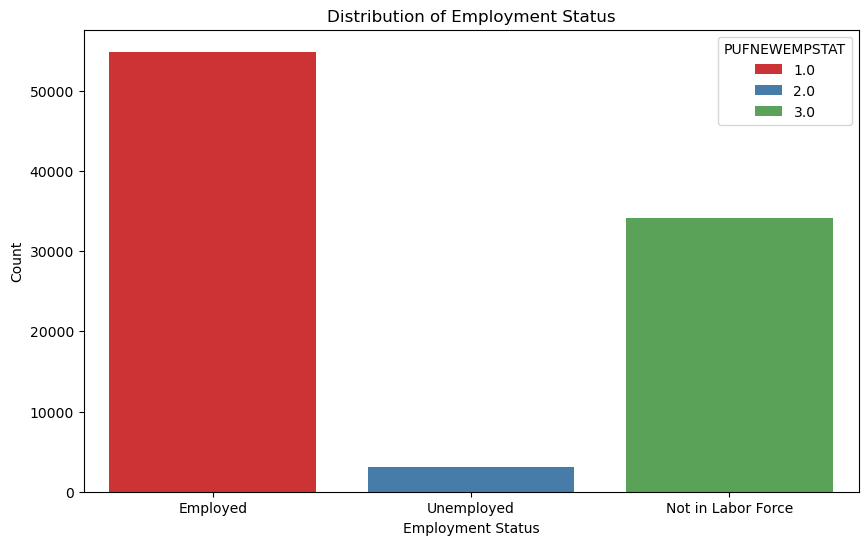

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PUFNEWEMPSTAT', hue='PUFNEWEMPSTAT', palette='Set1')
plt.title('Distribution of Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Employed', 'Unemployed', 'Not in Labor Force'])
plt.savefig("../figures/employment_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** The *employment class distributio* is ***highly imbalanced***, with the majority of individuals classified as `Employed` (*59.7%*), followed by `Not in the Labor Force` (*36.7%*), and a small minority as `Unemployed` (*3.6%*).

**Recommendation:** This imbalance suggests that special care (e.g., resampling or class weighting) may be needed during model training to avoid poor predictive performance on the underrepresented Unemployed class.

---
### 5.2. Demographic Insights

#### A. Age Distribution by Employment Status

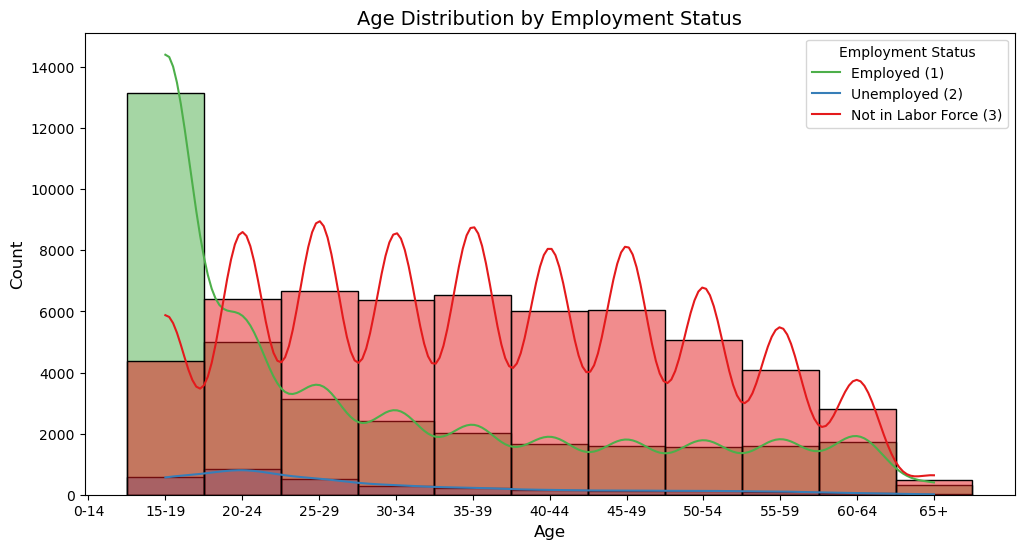

In [40]:
# Age Distribution by Employment Status
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=pd.cut(
    df['PUFC05_AGE'],
    bins=age_bins,
    labels=age_labels,
    right=True,   # Include the right edge (e.g., 19 is in '15-19')
    include_lowest=True
), hue='PUFNEWEMPSTAT', palette='Set1', bins=20, kde=True)
plt.title('Age Distribution by Employment Status', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(
    title='Employment Status',
    labels=['Employed (1)', 'Unemployed (2)', 'Not in Labor Force (3)'],
    fontsize=10
)
plt.savefig("../figures/age_distribution_by_employment.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:**
The histogram shows that most individuals who are `Employed` (green) are concentrated in the **15–24 age range**, with a steep drop-off in older age groups. The `Unemployed` (blue) population is consistently low across all ages, while those Not in the `Labor Force` (red) are more evenly distributed from ages 20 to 60, peaking slightly in the 20s and 30s.

This suggests that the labor force participation is highest among young adults, while a significant portion of older individuals may be inactive or have exited the labor market.

---
#### B. Education vs. Employment

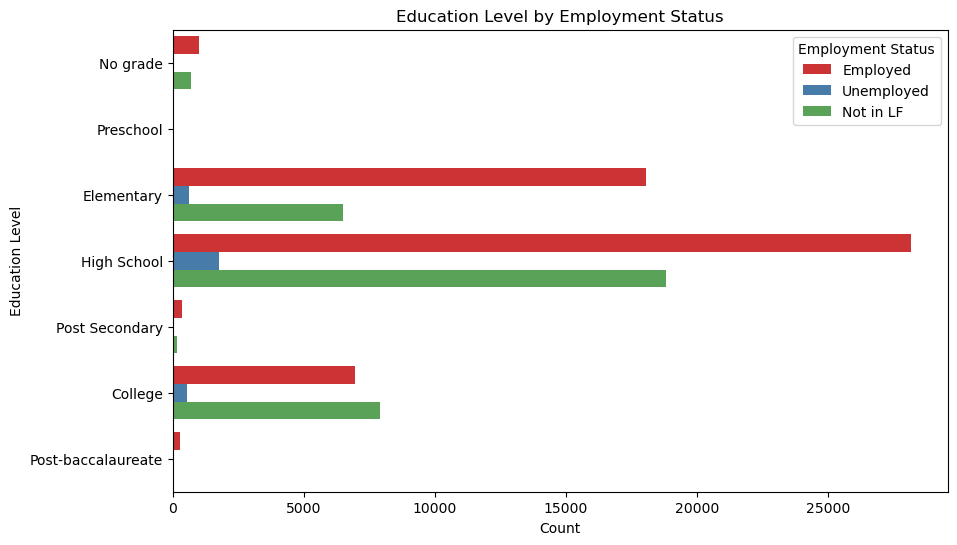

In [42]:
# Education vs. Employment
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y=df['PUFC07_GRADE'].map(education_level), hue='PUFNEWEMPSTAT', palette='Set1',
              order=['No grade', 'Preschool', 'Elementary','High School',
                     'Post Secondary', 'College', 'Post-baccalaureate'
])
plt.title('Education Level by Employment Status')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.legend(title='Employment Status', labels=['Employed', 'Unemployed', 'Not in LF'])
plt.savefig("../figures/education_vs_employment.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:**
This bar chart shows that individuals with *Elementary* and *High School* education levels make up the **largest portion** of the `Employed` group, while those with *High School education* also **dominate** the `Not in Labor Force` (NILF) category. Interestingly, `Unemployment` is relatively **low across all education levels**, but **slightly higher** among those with *College* and *Post-Secondary* education, indicating possible skills mismatch or underemployment.

---
#### C. Gender Differences

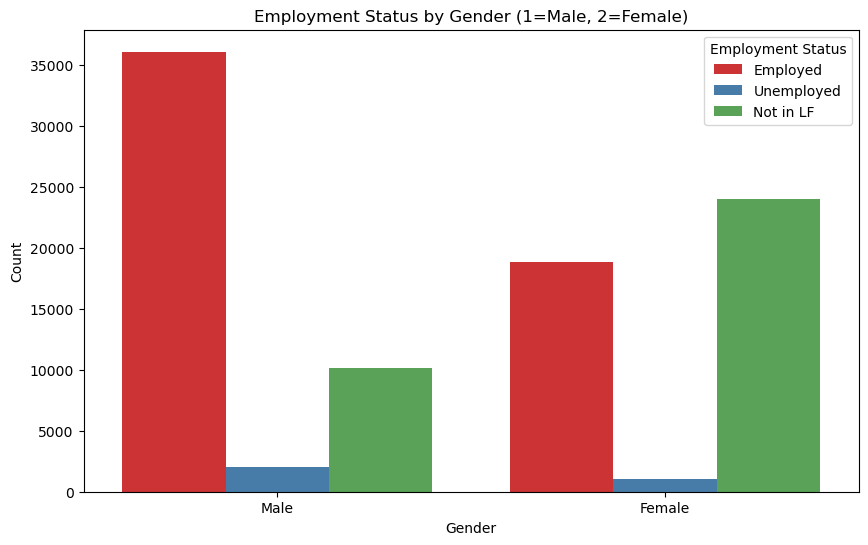

In [44]:
# Gender Differences
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PUFC04_SEX', hue='PUFNEWEMPSTAT', palette='Set1')
plt.title("Employment Status by Gender (1=Male, 2=Female)")
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Employment Status', labels=['Employed', 'Unemployed', 'Not in LF'])
plt.xticks([0, 1], ['Male', 'Female'], rotation=0)
plt.savefig("../figures/employment_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** A **larger proportion of males** are `Employed` compared to females, while **females dominate** the `Not in Labor Force` (NILF) category. `Unemployment` levels appear **relatively low for both genders**, but *slightly higher among males.*

The data suggests gender-based labor force participation disparities, likely driven by social, cultural, or caregiving roles disproportionately affecting women.

---
#### D. Marital Status and Employment

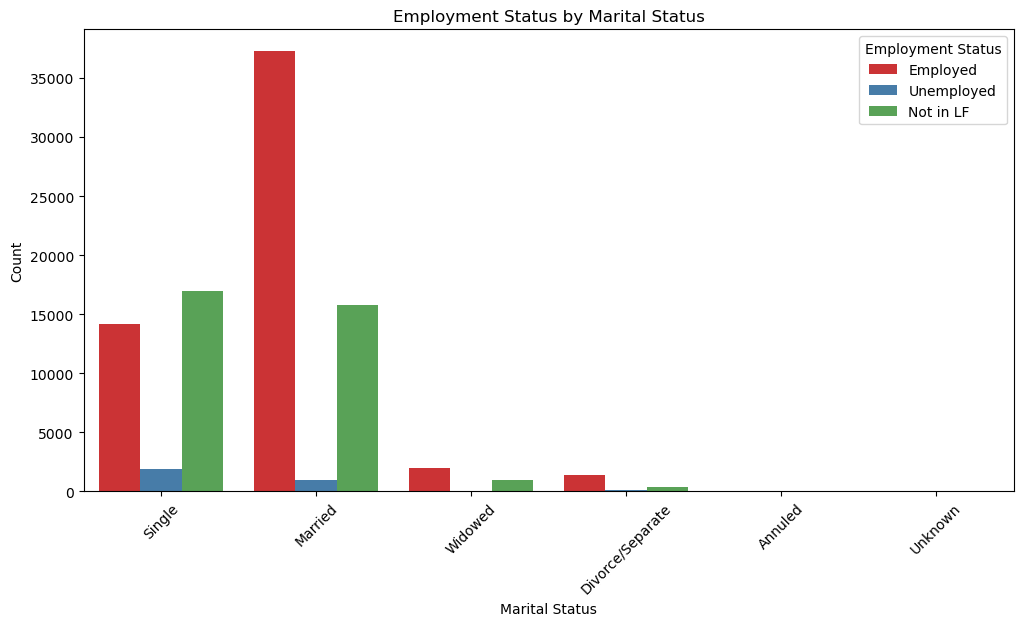

In [46]:
# Marital Status and Employment
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='PUFC06_MSTAT', hue='PUFNEWEMPSTAT', palette='Set1')
plt.title('Employment Status by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Employment Status', labels=['Employed', 'Unemployed', 'Not in LF'])
plt.xticks(ticks=range(len(marital_labels)), labels=[marital_labels[i] for i in sorted(marital_labels.keys())], rotation=45)
plt.legend(title='Employment Status', labels=['Employed', 'Unemployed', 'Not in LF'])
plt.savefig("../figures/employment_by_marital_status.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** *Married individuals* are **most likely** to be `Employed`, with a *significantly higher count of employment than any other marital status*. Meanwhile, *single individuals* show a more even split between being `Employed` and `Not in the labor force`, *suggesting variability in labor participation* based on life stage or responsibilities. `Unemployment` levels are *consistently low across all marital statuses.*

Marital status appears to influence employment outcomes, possibly due to differences in financial responsibility or household roles.

---
#### E. Urban vs. Rural Employment

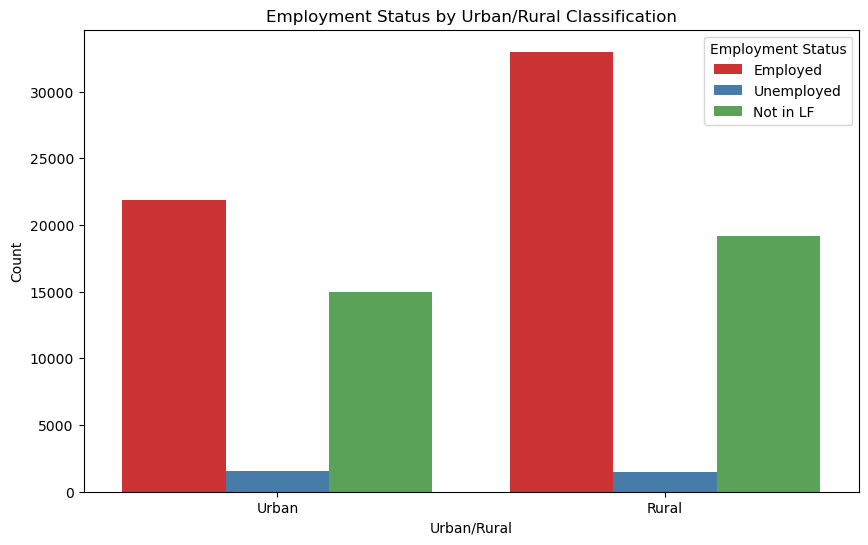

In [48]:
# Urban vs. Rural Employment
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PUFURB2K10', hue='PUFNEWEMPSTAT', palette='Set1')
plt.title('Employment Status by Urban/Rural Classification')
plt.xlabel('Urban/Rural')
plt.ylabel('Count')
plt.legend(title='Employment Status', labels=['Employed', 'Unemployed', 'Not in LF'])
plt.xticks([0, 1], ['Urban', 'Rural'], rotation=0)
plt.savefig("../figures/urban_vs_rural_employment.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:**
- *Rural areas* have the **highest** number of `Employed` individuals, followed by *urban areas*.
- *Both areas* have **very low** counts of `Unemployed` individuals, indicating that most people are either working or not participating in the labor force.
- Notably, *rural areas* also have a **high number** of individuals `Not in the Labor force`, suggesting a significant portion of the population may be outside formal employment or work-seeking activities.

---
### 5.3. Employment-Related Features

#### A. Hours Worked (Employed Only)

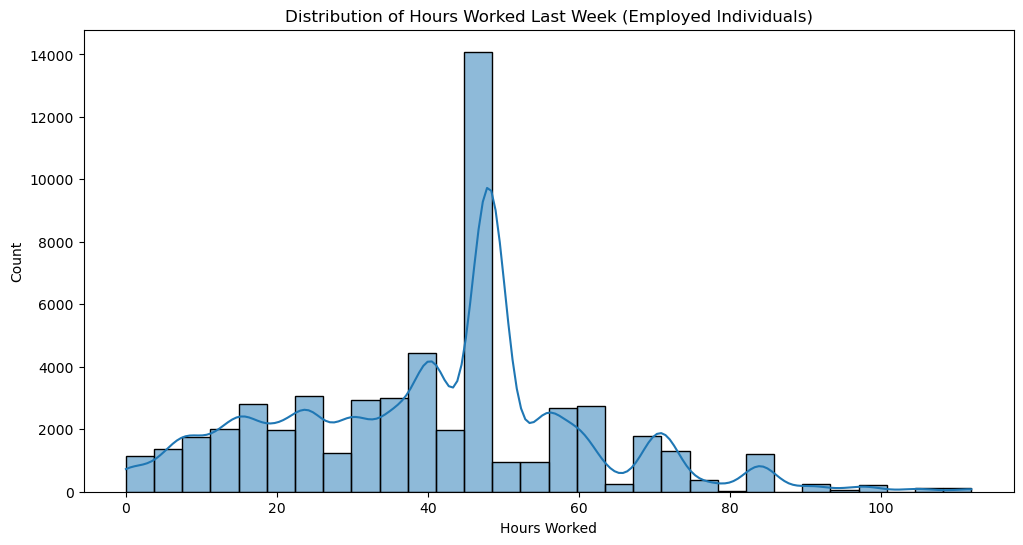

In [50]:
# Employment-Related Features
# Hours Worked (Employed Only)
employed = df[df['PUFNEWEMPSTAT'] == 1]
plt.figure(figsize=(12, 6))
sns.histplot(employed['PUFC19_PHOURS'].dropna(), bins=30, kde=True)
plt.title('Distribution of Hours Worked Last Week (Employed Individuals)')
plt.xlabel('Hours Worked')
plt.ylabel('Count')
plt.savefig("../figures/hours_worked_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** Most workers reported working around **40 hours**, forming a sharp peak in the center of the distribution, which aligns with standard full-time employment. There is noticeable variability, with some individuals working *significantly fewer or more hours*, including **over 60 to 100 hours**, indicating the presence of both *part-time* and possibly *overtime* or irregular work schedules.

---
#### B. Job Search Activity (Unemployed Only)

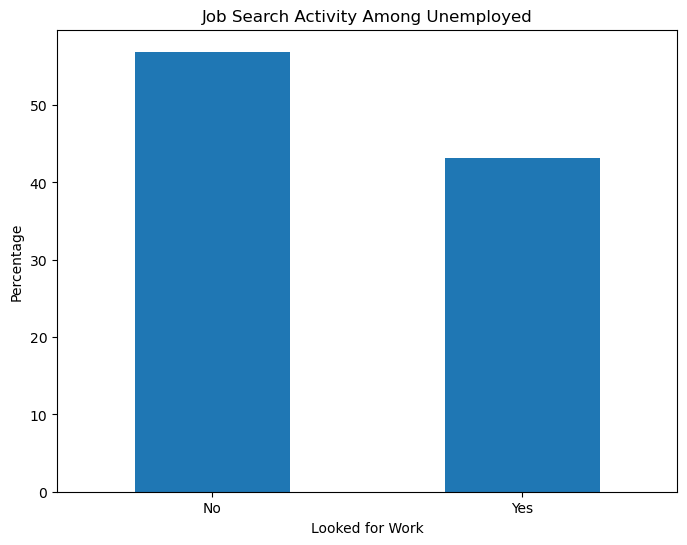

In [52]:
# Job Search Activity (Unemployed Only)
unemployed = df[df['PUFNEWEMPSTAT'] == 2]
job_search = unemployed['PUFC30_LOOKW'].value_counts(normalize=True) * 100
job_search.plot(kind='bar', figsize=(8, 6))
plt.title('Job Search Activity Among Unemployed')
plt.xlabel('Looked for Work')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.savefig("../figures/job_search_activity.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** A higher percentage of the `Unemployed` population (**over 55%**) did *not look for work*, while a smaller percentage (**around 45%**) *actively searched for a job*. This suggests that a significant portion of the unemployed may be disengaged from the labor market or face barriers to job-seeking.

---
### 5.4. Feature Correlation

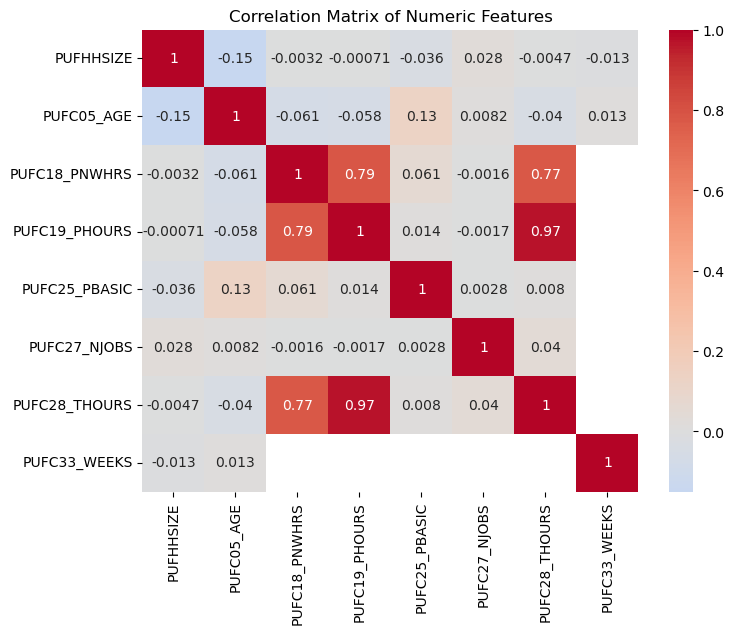

In [54]:
# Correlation Analysis
# Select numeric features for correlation and calculate correlations
corr_matrix = df[['PUFHHSIZE',         # Household size
                  'PUFC05_AGE',        # Age
                  'PUFC18_PNWHRS',     # Normal working hours per day
                  'PUFC19_PHOURS',     # Total hours worked (past week)
                  'PUFC25_PBASIC',     # Basic pay per day
                  'PUFC27_NJOBS',      # Number of jobs held
                  'PUFC28_THOURS',     # Total hours worked (all jobs)
                  'PUFC33_WEEKS'       # Weeks spent looking for work
]].corr()
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.savefig("../figures/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:**
- Most variables show **weak to moderate correlations**, indicating minimal linear dependence.
- `PUFC19_PHOURS` (total hours worked in the past week) is **highly correlated** with `PUFC28_THOURS` (total hours worked in all jobs) at 0.97, suggesting they may measure overlapping concepts.
- Similarly, `PUFC18_PNWHRS` (normal working hours per day) also **correlates strongly** with both `PUFC19_PHOURS` (0.79) and `PUFC28_THOURS` (0.77), which is expected due to their related nature.
- Most other variables, such as `PUFHHSIZE`, `PUFC05_AGE`, and `PUFC25_PBASIC`, have **weak or negligible correlations** with other features, indicating that they contribute more unique information to the dataset.

**Recommendation:** This matrix suggests ***potential multicollinearity*** between some time-related work variables, which should be addressed before modeling, especially in regression contexts.

### Feature Selection

For selecting **categorical features**, we have chosen to use:
- ***Chi-square test***
- ***Cramer's V test***

A ***high Chi-square value*** with a *low p-value (<0.05)* usually means there is a *statistically significant relationship* between two categorical variables.


Cramér’s V also measures the relationship between two categorical variables and is derived from the calculations of Chi-square.

**Note:** Only the values from Cramer's V will be used for the ranking and selection of features since it is less sensitive to the large sample size of the dataset compared to the p-values of Chi-square.

***Cramér’s V Strength of Association:***
- more than 0.5, *Very Strong*
- 0.3 – 0.5, *Strong*
- 0.2 – 0.3, *Moderate*
- 0.1 – 0.2, *Weak*
- < 0.1, *Very weak / Negligible*

All the categorical variables are being compared to our target variable `PUFNEWEMPSTAT`. The features marked weak and below will be dropped.

In [57]:
# Feature Selection
# Categorical Feature Screening using Cramér’s V
cat_results = []

for col in [c for c in categorical_features if c in df.columns]:
    ser = df[col].astype(str).fillna('NA')
    tab = pd.crosstab(ser, df['PUFNEWEMPSTAT'])

    if tab.values.sum() == 0 or tab.shape[0] < 2:
        cat_results.append((col, np.nan, np.nan, np.nan, "no_data"))
        continue

    # Chi2 test and Cramér’s V calculation
    chi_2, p, dof, expected = chi2_contingency(tab)
    n = tab.values.sum()
    phi2 = chi_2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    denom = min((kcorr - 1), (rcorr - 1))
    cramers_v = np.sqrt(phi2corr / denom) if denom > 0 else np.nan

    # Use only Cramér’s V to label strength
    if cramers_v >= 0.5:
        strength = "very_strong"
    elif cramers_v >= 0.3:
        strength = "strong"
    elif cramers_v >= 0.2:
        strength = "moderate"
    elif cramers_v >= 0.1:
        strength = "weak"
    else:
        strength = "very_weak"

    cat_results.append((col, chi_2, p, cramers_v, strength))

# Create sorted results table
cat_results_df = pd.DataFrame(cat_results,
                              columns=['Feature','chi_2','p_value','cramers_v','strength']) \
                    .sort_values(by='cramers_v', ascending=False)

# Print results
print("\nCategorical Feature Screening (Cramér’s V only):")
print(cat_results_df.to_string(index=False))


Categorical Feature Screening (Cramér’s V only):
        Feature         chi_2       p_value  cramers_v    strength
  PUFNEWEMPSTAT 184116.000000  0.000000e+00   1.000000 very_strong
    PUFC11_WORK  89529.038100  0.000000e+00   0.986163 very_strong
   PUFC34_WYNOT 126182.217467  0.000000e+00   0.827803 very_strong
   PUFC30_LOOKW 125101.417018  0.000000e+00   0.824296 very_strong
 PUFC38_PREVJOB  95464.039266  0.000000e+00   0.720062 very_strong
   PUFC36_AVAIL  94207.604574  0.000000e+00   0.715307 very_strong
   PUFC22_PFWRK  92058.000000  0.000000e+00   0.707099 very_strong
  PUFC20_PWMORE  92058.000000  0.000000e+00   0.707099 very_strong
     PUFC12_JOB  92058.000000  0.000000e+00   0.707099 very_strong
  PUFC21_PLADDW  92058.000000  0.000000e+00   0.707099 very_strong
    PUFC26_OJOB  92058.000000  0.000000e+00   0.707099 very_strong
   PUFC17_NATEM  92058.000000  0.000000e+00   0.707091 very_strong
  PUFC23_PCLASS  92058.000000  0.000000e+00   0.707061 very_strong
   PUFC14_PR

For **numeric feature selection**, we will use:
- ***ANOVA test***

***Analysis of Variance*** is a statistical method that assesses the relation between numeric features and a categorical target. 

Before it can be applied however, the values in the numeric features must be made sure to be strictly numeric only hence the code to convert values. There is also a rule of thumb that if there are fewer than twenty observations in the feature, it must be dropped.

Based on standard thresholds (Cohen's conventions for ANOVA effect sizes):

| η² Threshold     | Interpretation | Meaning                                                       |
|------------------|----------------|---------------------------------------------------------------|
| **≥ 0.14**        | `large_effect` | Strong association; explains a substantial portion of variance |
| **0.06 – 0.14**   | `medium_effect`| Moderate association                                           |
| **0.01 – 0.06**   | `small_effect` | Weak but potentially meaningful association                   |
| **< 0.01**        | `very_weak`    | Minimal effect; likely not useful for prediction              |
| **NaN or missing**| `no_data`      | Insufficient or invalid data to compute effect size           |

In [59]:
#ANOVA F-test for numeric features
num_results = []
classes = df['PUFNEWEMPSTAT'].unique()

for col in numeric_features:
    # Use numeric conversion; coerce invalids to NaN
    vals = pd.to_numeric(df[col], errors='coerce')
    grp_data = []
    ok = True
    for cls in classes:
        g = vals[df['PUFNEWEMPSTAT'] == cls].dropna().values
        if g.size < 20:  # too few obs → skip
            ok = False
            break
        grp_data.append(g)
    if not ok:
        num_results.append((col, np.nan, np.nan, np.nan, "too_few_data"))
        continue

    # ANOVA
    F, p = stats.f_oneway(*grp_data)

    # eta squared
    all_vals = vals.dropna().values
    grand_mean = np.mean(all_vals)
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in grp_data)
    ss_total = np.sum((all_vals - grand_mean)**2)
    eta_sq = ss_between / ss_total if ss_total > 0 else np.nan

    if eta_sq >= 0.14:
        note = "large_effect"
    elif eta_sq >= 0.06:
        note = "medium_effect"
    elif eta_sq >= 0.01:
        note = "small_effect"
    elif not np.isnan(eta_sq):
        note = "very_weak"
    else:
        note = "no_data"

    num_results.append((col, F, p, eta_sq, note))

num_results_df = pd.DataFrame(num_results,
                              columns=['Feature','F_stat','p_value','eta_sq','note']) \
                    .sort_values(by='eta_sq', ascending=False)

print("Numeric Feature Screening (ANOVA):")
print(num_results_df.to_string(index=False))

Numeric Feature Screening (ANOVA):
      Feature      F_stat       p_value   eta_sq          note
   PUFC05_AGE 4065.701091  0.000000e+00 0.081163 medium_effect
    PUFHHSIZE  269.991449 1.221148e-117 0.005832     very_weak
PUFC18_PNWHRS         NaN           NaN      NaN  too_few_data
PUFC19_PHOURS         NaN           NaN      NaN  too_few_data
PUFC25_PBASIC         NaN           NaN      NaN  too_few_data
 PUFC27_NJOBS         NaN           NaN      NaN  too_few_data
PUFC28_THOURS         NaN           NaN      NaN  too_few_data
 PUFC33_WEEKS         NaN           NaN      NaN  too_few_data


---
**Conclusion:** It seems like the main predictors for employment status will mostly come from the categorical features. Based on the results this is a breakdown of the features being dropped.

---
### Feature Removal (Statistical Tests)

**Justification:**

The following features were removed based strictly on the results of statistical screening (Cramér’s V for categorical variables and ANOVA for numeric variables):

| Feature          | Reason for Drop                  | Method        |
|------------------|----------------------------------|---------------|
| `PUFC18_PNWHRS`    | Too few valid observations       | ANOVA         |
| `PUFC19_PHOURS`    | Too few valid observations       | ANOVA         |
| `PUFC25_PBASIC`    | Too few valid observations       | ANOVA         |
| `PUFC28_THOURS`    | Too few valid observations       | ANOVA         |
| `PUFC27_NJOBS`     | Too few valid observations       | ANOVA         |
| `PUFC33_WEEKS`     | Too few valid observations       | ANOVA         |
| `PUFC31_FLWRK`     | Low association, high missingness| Cramér’s V    |
| `PUFC32_JOBSM`     | Low association, high missingness| Cramér’s V    |
| `PUFC35_LTLOOKW`  | Weak association (V < 0.2)       | Cramér’s V    |
| `PUFC36_AVAIL`     | Very high missing rate           | Cramér’s V    |
| `PUFC37_WILLING`   | Very high missing rate           | Cramér’s V    |
| `PUFC29_WWM48H`    | Moderate association (V ≈ 0.25)  | Cramér’s V    |
| `PUFC08_CURSCH`    | Moderate association (V ≈ 0.29)  | Cramér’s V    |

>**Note**: Some dropped features like `PUFC26_OJOB`, `PUFC21_PLADDW`, and `PUFC30_LOOKW` had strong statistical association with `PUFNEWEMPSTAT`, but were excluded due to high missingness or conditional skip patterns, which limit their reliability across the full dataset.

The next code block also presents the final list of features to be included in the study before we split the data.

In [61]:
# Drop features with moderate missingness and weak statistical support
drop_features = [
    'PUFC18_PNWHRS',     # Normal working hours per day
    'PUFC19_PHOURS',     # Total hours worked during past week
    'PUFC28_THOURS',     # Total hours worked in all jobs
    'PUFC25_PBASIC',     # Basic pay per day
    'PUFC26_OJOB',       # Had another job/business
    'PUFC21_PLADDW',     # Looked for additional work
    'PUFC22_PFWRK',      # First time to work
    'PUFC30_LOOKW',      # Looked for work/business
    'PUFC34_WYNOT',      # Reason for not looking for work
    'PUFC38_PREVJOB'     # Has previously worked
]

df.drop(columns=drop_features, inplace=True, errors='ignore')

# Drop high-missing or unused variables
high_missing = [
    'PUFC35_LTLOOKW',    # Last time looked for work
    'PUFC31_FLWRK',      # First time looking for work
    'PUFC32_JOBSM',      # Job search method
    'PUFC33_WEEKS',      # Weeks spent looking for work
    'PUFC27_NJOBS',      # Number of jobs
    'PUFC36_AVAIL',      # Available for work
    'PUFC37_WILLING',    # Willing to work
    'PUFC29_WWM48H',     # Reason for working less than 48 hours
    'PUFC40_POCC',       # Previous occupation
    'PUFC08_CURSCH',     # Currently attending school
    'PUFC12_JOB',        # Had a job/business despite not working
    'PUFC20_PWMORE',     # Wants more hours
    'PUFC43_QKB',        # Kind of business 
    'PUFC41_WQTR'        # Worked in past quarter
]

df.drop(columns=high_missing, inplace=True, errors='ignore')

# Drop label leakage variables if they exist
leakage_features = [
    'PUFC11_WORK',   # Did any work during the past week
    'PUFC12_JOB',    # Had a job/business even if not working
    'PUFC30_LOOKW'   # Looked for work or tried to start a business
]

df.drop(columns=leakage_features, inplace=True, errors='ignore')


# Display final list of retained features
retained_features = df.columns.tolist()
print(f"Final feature count: {len(retained_features)}")
print("Final feature list:")
for f in retained_features:
    print(f" - {f}")

Final feature count: 25
Final feature list:
 - PUFREG
 - PUFPRV
 - PUFPRRCD
 - PUFURB2K10
 - PUFHHSIZE
 - PUFC03_REL
 - PUFC04_SEX
 - PUFC05_AGE
 - PUFC06_MSTAT
 - PUFC07_GRADE
 - PUFC09_GRADTECH
 - PUFC10_CONWR
 - PUFC14_PROCC
 - PUFC16_PKB
 - PUFC17_NATEM
 - PUFC23_PCLASS
 - PUFC24_PBASIS
 - PUFNEWEMPSTAT
 - PUFC35_LTLOOKW_FLAG
 - PUFC33_WEEKS_FLAG
 - PUFC32_JOBSM_FLAG
 - PUFC31_FLWRK_FLAG
 - PUFC27_NJOBS_FLAG
 - PUFC37_WILLING_FLAG
 - PUFC36_AVAIL_FLAG


In [62]:
# Final remaining columns (excluding target and _FLAGs)
features = [col for col in df.columns if col != 'PUFNEWEMPSTAT' and not col.endswith('_FLAG')]

# Categorical features based on Cramer's V
manual_categorical = [
    'PUFREG',           # Region code
    'PUFPRV',           # Province code
    'PUFPRRCD',         # Province recode
    'PUFURB2K10',       # Urban/Rural classification
    'PUFC03_REL',       # Relationship to household head
    'PUFC04_SEX',       # Sex
    'PUFC06_MSTAT',     # Marital status
    'PUFC07_GRADE',     # Highest grade completed
    'PUFC09_GRADTECH',  # Graduate of vocational/technical course
    'PUFC10_CONWR',     # Category of Overseas Filipino Worker (OFW)
    'PUFC14_PROCC',     # Primary occupation
    'PUFC16_PKB',       # Kind of business or industry
    'PUFC17_NATEM',     # Nature of employment
    'PUFC23_PCLASS'     # Class of worker
]

# Flags
flag_features = [col for col in df.columns if col.endswith('_FLAG')]

# Now split the rest
categorical_features = [col for col in manual_categorical if col in df.columns]
numeric_features = [col for col in features if col not in categorical_features]

# Output
print("Categorical Features:")
for col in categorical_features:
    print(f" - {col}")

print("\nNumeric Features:")
for col in numeric_features:
    print(f" - {col}")

print("\nMissing Value Flag Features:")
for col in flag_features:
    print(f" - {col}")

print(f"\nSummary:")
print(f" - {len(categorical_features)} categorical features")
print(f" - {len(numeric_features)} numeric features")
print(f" - {len(flag_features)} missing flags")

Categorical Features:
 - PUFREG
 - PUFPRV
 - PUFPRRCD
 - PUFURB2K10
 - PUFC03_REL
 - PUFC04_SEX
 - PUFC06_MSTAT
 - PUFC07_GRADE
 - PUFC09_GRADTECH
 - PUFC10_CONWR
 - PUFC14_PROCC
 - PUFC16_PKB
 - PUFC17_NATEM
 - PUFC23_PCLASS

Numeric Features:
 - PUFHHSIZE
 - PUFC05_AGE
 - PUFC24_PBASIS

Missing Value Flag Features:
 - PUFC35_LTLOOKW_FLAG
 - PUFC33_WEEKS_FLAG
 - PUFC32_JOBSM_FLAG
 - PUFC31_FLWRK_FLAG
 - PUFC27_NJOBS_FLAG
 - PUFC37_WILLING_FLAG
 - PUFC36_AVAIL_FLAG

Summary:
 - 14 categorical features
 - 3 numeric features
 - 7 missing flags


---
## Section 6: Model Training
- We used three machine learning models such as Multinomial Logistic Regression, XGBoost and Categorical Naive Bayes. 
---
### Train-Test-Validation Split
- We will now split the dataset to be shared across all models.

**Note:** **`Label Encode`** the target variable

All three models expects the target `y` to be:
- A 1D array of integer class labels, like: `[0, 1, 2]`
- Each integer represents a different class.

In [64]:
# Split data into features (X) and target (y)
X = df.drop(columns=['PUFNEWEMPSTAT'])

# Encode target variable y to start from 0
le_y = LabelEncoder()
y = le_y.fit_transform(df['PUFNEWEMPSTAT'])

### Train-test split (80% train, 20% test), stratified to maintain class distribution

In [66]:
# Train-test split (80% train, 20% test)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

### Validation split from training data (60% train, 20% validation), again stratified

In [68]:
# Train-validation split from training data (75% train, 25% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42)

The final proportions are:
- **Train:** *60%* of total
- **Validation:** *20%* of total
- **Test:** *20%* of total

In [70]:
# Examine class distribution
class_counts = df['PUFNEWEMPSTAT'].value_counts()
class_percent = df['PUFNEWEMPSTAT'].value_counts(normalize=True) * 100
imbalance_df = pd.DataFrame({'Count': class_counts, 'Percentage': class_percent.round(2)})
print("Employment Class Distribution (PUFNEWEMPSTAT):")
print(imbalance_df)

Employment Class Distribution (PUFNEWEMPSTAT):
               Count  Percentage
PUFNEWEMPSTAT                   
1.0            54880       59.61
3.0            34148       37.09
2.0             3030        3.29


---
## Model 1: Multinomial Logistic Regression

### Encoding Strategy for Categorical Features

| Encoder            | Use Case                                                      | Applied To                                         |
| ------------------ | ------------------------------------------------------------- | -------------------------------------------------- |
| **`TargetEncoder`**  | High-cardinality categorical variables with predictive signal | `PUFPRV`, `PUFC07_GRADE`, `PUFC14_PROCC`, `PUFC16_PKB` |
| **`OneHotEncoder`**  | Low-cardinality nominal categorical variables                 | `PUFREG`, `PUFURB2K10`, `PUFC03_REL`, `PUFC04_SEX`, `PUFC06_MSTAT`, `PUFC09_GRADTECH`, `PUFC17_NATEM`, `PUFC23_PCLASS` |
| **`OrdinalEncoder`** | Ordinal variables with implicit order                         | `PUFPRRCD` |

**Justification:**

For features `PUFPRV` (Province Code), `PUFC07_GRADE`(Highest Grade Completed), `PUFC14_PROCC` (Occupation), and `PUFC16_PKB`(Kind of Business/Industry), use **`TargetEncoder`**:
- These have high cardinality and likely contain predictive signal. Target encoding reduces dimensionality and captures correlation with the target.

For features `PUFREG` (Region Code), `PUFURB2K10` (Urban/Rural), `PUFC03_REL` (Relationship to household head), `PUFC04_SEX` (Sex), `PUFC06_MSTAT` (Marital status), `PUFC09_GRADTECH` (Graduate of vocational/technical course), `PUFC10_CONWR` (Category of OFW), `PUFC17_NATEM` (Nature of Employment), and `PUFC23_PCLASS` (Class of Worker), use **`OneHotEncoder`**:
- These have low to moderate cardinality and represent nominal categories. One-hot avoids implicit ordinality, which suits MLR’s assumptions.

For features `PUFPRRCD` (Province recode, use **`OrdinalEncoder`**:
- Zip code or province recode may have slight ordinality or be difficult to handle otherwise. Ordinal encoding preserves category identity simply.

**Note:** For numeric variables, use **`StandardScaler()`** to standardize them.

In [73]:
targetenc_features = ['PUFPRV', 'PUFC07_GRADE', 'PUFC14_PROCC', 'PUFC16_PKB']

onehot_features = [
    'PUFREG', 'PUFURB2K10', 'PUFC03_REL', 'PUFC04_SEX',
    'PUFC06_MSTAT', 'PUFC09_GRADTECH', 'PUFC10_CONWR',
    'PUFC17_NATEM', 'PUFC23_PCLASS'
]

ordinal_features = ['PUFPRRCD']

Fill in missing values in numeric columns using `SimpleImputer(strategy='median')`.
- Median is robust to outliers and preserves the central tendency.

Standardizes numeric features by removing the mean and scaling to unit variance.
- This is important for models that are sensitive to feature scale like logistic regression.

In [75]:
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Fill missing values in categorical columns using the most frequent (mode) value via `SimpleImputer(strategy='most_frequent')`.

Encode categorical variables as binary vectors using `OneHotEncoder()`.

**Note:** The `handle_unknown='ignore'` option ensures the transformer doesn’t crash on unseen categories during inference.

In [77]:
# One-hot encoding pipeline
onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

Fill missing values for ordinal features using the most frequent category via `SimpleImputer(strategy='most_frequent')`.

Converts ordered categorical variables into integer values that reflect their rank using `OrdinalEncoder()`.

**Note:** The `unknown_value=-1` ensures unseen labels are handled during inference.

In [79]:
# Ordinal encoding pipeline
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

Handle missing values in high-cardinality categorical variables using `SimpleImputer(strategy='most_frequent')`.

Replace each category with the mean of the target variable for that category using `TargetEncoder()`.
**Note**: Useful when there are many unique levels.

In [81]:
# Target encoding pipeline
target_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder())
])

Binary flag features (0/1 indicators) are passed through without transformation, as they are already numeric and interpretable.

In [83]:
# Pass-through for binary flags (no transformation)
# You may scale if they’re not binary, but usually 0/1 flags don’t need it
flags_transformer = 'passthrough'

### Combine All Transformers

Combines all preprocessing steps for different feature types using `ColumnTransformer()`.
- This allows parallel and clean transformation of different column groups before feeding into the model.

In [85]:
# Combine into column transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('onehot', onehot_transformer, onehot_features),
    ('ordinal', ordinal_transformer, ordinal_features),
    ('target', target_transformer, targetenc_features),
    ('flags', flags_transformer, flag_features)
])

### Final Modelling Pipeline

- `Pipeline`: Bundles preprocessing and modeling into a single object.
- `LogisticRegression`: Chosen classifier. `class_weight='balanced'` adjusts for class imbalance by giving minority classes more weight.
- `solver='lbfgs'`: Optimizer suitable for multinomial logistic regression.
- `max_iter=5000`: Increases maximum iterations to ensure convergence.

In [87]:
# Build final pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=5000,
        class_weight='balanced'
    ))
])

### Hyperparameter Tuning by `RandomizedSearchCV`

Define the search space for tuning hyperparameters of the classifier:

- `C`: Regularization strength (inverse of penalty).
- `solver`: Optimization algorithm.
- `class_weight`: Whether to use balanced class weights or not.

In [89]:
# Define parameter grid for hyperparameter tuning
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs'],
    'classifier__class_weight': ['balanced', None]
}

**Note:**

- `f1_macro`: Metric used for scoring; gives equal importance to all classes.
- `cv=3`: 3-fold cross-validation.
- `n_iter=10`: Samples 10 combinations from the param grid.
- `n_jobs=-1`: Uses all CPU cores for parallel computation.

In [91]:
# Randomized search for tuning
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

### Model Fitting and Training

In [93]:
# Fit the model to training data
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['PUFHHSIZE',
                                                                                'PUFC05_AGE',
                                                                                'PUFC24_PBASIS']),
                                                                              ('onehot',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_u...
                                                                                'PUFC31_FLWRK_FLAG',
                                                                                'PUFC27_NJOBS_FLAG',
                                                                                'PUFC37_WILLING_FLAG',
                                                                                'PUFC36_AVAIL_FLAG'])])),
                                             ('classifier',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=5000))]),
                   n_jobs=-1,
                   param_distributions={'classifier__C': [0.001, 0.01, 0.1, 1,
                                                          10],
                                        'classifier__class_weight': ['balanced',
                                                                     None],
                                        'classifier__solver': ['lbfgs']},
                   random_state=42, scoring='f1_macro', verbose=1)

### Display Top 10 Hyperparameter Configurations

After performing hyperparameter tuning using `RandomizedSearchCV`, we examine the top 10 configurations based on cross-validation performance.

In [95]:
# Create a DataFrame of cross-validation results
cv_results_df = pd.DataFrame(random_search.cv_results_)

# Sort by rank test score and display top 10 configurations
top_10 = cv_results_df.sort_values(by='rank_test_score').head(10)

# Display relevant columns
print("\nTop 10 Hyperparameter Configurations:")
print(top_10[[
    'params', 
    'mean_test_score', 
    'std_test_score', 
    'rank_test_score'
]])


Top 10 Hyperparameter Configurations:
                                              params  mean_test_score  \
7  {'classifier__solver': 'lbfgs', 'classifier__c...         0.931513   
9  {'classifier__solver': 'lbfgs', 'classifier__c...         0.931046   
5  {'classifier__solver': 'lbfgs', 'classifier__c...         0.930664   
8  {'classifier__solver': 'lbfgs', 'classifier__c...         0.929031   
6  {'classifier__solver': 'lbfgs', 'classifier__c...         0.928695   
4  {'classifier__solver': 'lbfgs', 'classifier__c...         0.927441   
2  {'classifier__solver': 'lbfgs', 'classifier__c...         0.924199   
3  {'classifier__solver': 'lbfgs', 'classifier__c...         0.923079   
0  {'classifier__solver': 'lbfgs', 'classifier__c...         0.905290   
1  {'classifier__solver': 'lbfgs', 'classifier__c...         0.777980   

   std_test_score  rank_test_score  
7        0.004084                1  
9        0.003728                2  
5        0.004734                3  
8        

Each row in the table below represents a different combination of hyperparameters tested using `RandomizedSearchCV` during model tuning. The tuning focused on the following:

- `classifier__C`: the inverse of regularization strength (smaller values specify stronger regularization),

- `classifier__solver`: the optimization algorithm used by LogisticRegression (lbfgs was used for all),

- `classifier__class_weight`: whether to apply class balancing ('balanced' vs. None).

The goal was to maximize the macro F1-score, which treats each class equally and is appropriate for imbalanced classification tasks.

| Rank | Solver | C Value | Class Weight | Mean F1 Score | Std Dev | Notes                                |
| ---- | ------ | ------- | ------------ | ------------- | ------- | ------------------------------------ |
| 1    | lbfgs  | 10      | balanced     | 0.9315        | 0.0041  | Best overall                         |
| 2    | lbfgs  | 0.1     | balanced     | 0.9310        | 0.0037  | High performance with moderate C     |
| 3    | lbfgs  | 1       | balanced     | 0.9307        | 0.0047  | Strong generalization                |
| 4    | lbfgs  | 0.01    | balanced     | 0.9290        | 0.0034  | Smaller C, stronger regularization   |
| 5    | lbfgs  | 0.001   | balanced     | 0.9287        | 0.0034  | More regularization, still effective |
| 6    | lbfgs  | 10      | None         | 0.9274        | 0.0035  | Unbalanced, slightly lower           |
| 7    | lbfgs  | 0.001   | None         | 0.9242        | 0.0034  | No balancing, higher bias            |
| 8    | lbfgs  | 0.01    | None         | 0.9231        | 0.0055  | Slightly less stable                 |
| 9    | lbfgs  | 1       | None         | 0.9053        | 0.0034  | Lower accuracy without balancing     |
| 10   | lbfgs  | 0.1     | None         | 0.7780        | 0.0005  | Worst performer among top 10         |


In [97]:
# Extract the best-performing pipeline from the randomized search
final_mlr = random_search.best_estimator_

### Model Generalization Check: Overfitting vs. Underfitting

Make predictions on the validation set 

In [99]:
# Predict and evaluate on validation set
y_pred_val = final_mlr.predict(X_val)
print("\nValidation Set Evaluation:")
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))


Validation Set Evaluation:
[[10835     0   141]
 [    0   541    65]
 [   33   137  6660]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10976
           1       0.80      0.89      0.84       606
           2       0.97      0.98      0.97      6830

    accuracy                           0.98     18412
   macro avg       0.92      0.95      0.94     18412
weighted avg       0.98      0.98      0.98     18412



**Interpretation:**

**Confustion Matrix (Validation Set)**

Class 0 (*Majority class*):

- Extremely high accuracy (f1-score): **99%**
- Only 141 misclassified as Class 3.0

Class 1 (*Minority class*):

- Moderate performance (f1-score): **84%**
- 65 misclassified as Class 3.0

Class 2 (*Second-largest class*):

- High accuracy (f1-score): **98%**
- 33 misclassified as Class 1.0
- 137 misclassified as Class 2.0

Validation Accuracy: **98%**

F1-Scores:
- High across all classes, especially 1.0 and 3.0
- Slightly lower for minority class 2.0 — *typical in imbalanced datasets*

---
### Final model evaluation on unseen test data to estimate generalization performance

In [101]:
# Predict and evaluate on test set
y_pred_test = final_mlr.predict(X_test)
print("\nFinal Test Set Evaluation:")
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))


Final Test Set Evaluation:
[[10817     0   159]
 [    0   538    68]
 [   49   172  6609]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10976
           1       0.76      0.89      0.82       606
           2       0.97      0.97      0.97      6830

    accuracy                           0.98     18412
   macro avg       0.91      0.95      0.93     18412
weighted avg       0.98      0.98      0.98     18412



**Interpretation:**

**Confusion Matrix (Test Set):**

Class 0 (*Majority*):
- Extremely high precision and recall: 10,817/10,976 = 98.6% recall
- Misclassifies 159 as Class 3.0

Class 1 (*Minority*):
- Slight drop in precision: 76%
- Recall remains strong: 89%
- 68 misclassified as Class 3.0

Class 2:
- High performance: ~97% recall and precision
- Misclassifies 49 as Class 1.0 and 172 as Class 2.0

Test Set Accuracy: **98%**

**Observations:**
- Consistent accuracy between validation and test sets. Model generalizes well.
- Class 2.0 shows slight precision drop, expected due to class imbalance and fewer examples.
- No significant overfitting; performance is steady across unseen data.

**Recommendation:** The model is reliable for deployment or downstream analysis.

To further improve performance on Class 2.0, consider:
- Class rebalancing (e.g., SMOTE or stratified sampling),
- Cost-sensitive learning (adjusting class weights),
- Feature selection to reduce noise and enhance minority class separation.

Maintain the current preprocessing strategy, as it demonstrates strong generalizability.

---
## Model 2: XGBoost
Next we will apply `OrdinalEncoder` for the Categorical Features. `XGBoost` does not require one-hot encoding, because it doesn't assume linear relationships between features and outcomes. It preserves the categorical identity of features without adding unnecessary dimensions.

`XGBoost` will treat these values as nominal categories and find optimal splits during training. We have also chosen not to include imputing values only for the `XGBoost` ensemble model since it can handle missing values natively.

In [104]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Apply encoding to resampled training set
X_train[categorical_features] = encoder.fit_transform(X_train[categorical_features])

# Apply the same encoder to validation and test sets
X_val[categorical_features]  = encoder.transform(X_val[categorical_features])
X_test[categorical_features] = encoder.transform(X_test[categorical_features])

Even though we used `OrdinalEncoder`, Pandas sometimes keeps the dtype of those columns as category, especially if the original `df[col]` was categorical before encoding.

- So we explicitly convert everything to a numeric format (`float32`) that XGBoost is guaranteed to accept:

In [106]:
# Force all X inputs to be float32 (required by XGBoost)
X_train = X_train.astype('float32')
X_val   = X_val.astype('float32')
X_test  = X_test.astype('float32')

### Hyperparameter Tuning for XGBoost Classifier

To optimize the performance of the XGBoost model, we employed **RandomizedSearchCV** for hyperparameter tuning. This method randomly samples a fixed number of hyperparameter combinations from specified distributions and evaluates them using cross-validation. Compared to Grid Search, Randomized Search is more efficient when tuning over large or continuous parameter spaces.

#### Tuning Method: Randomized Search
- **Cross-validation strategy**: 3-fold cross-validation
- **Scoring metric**: `f1_macro` – appropriate for imbalanced multiclass classification as it gives equal weight to each class.
- **Number of iterations**: 30 randomly sampled configurations (`n_iter=30`)
- **Parallelism**: Fully parallelized using `n_jobs=-1`

#### Hyperparameters Tuned and Their Search Spaces

| Hyperparameter      | Description                                                             | Range / Distribution                     |
|---------------------|-------------------------------------------------------------------------|-------------------------------------------|
| `n_estimators`      | Number of boosting rounds (trees)                                       | Random integer between 50 and 300         |
| `max_depth`         | Maximum tree depth                                                      | Random integer between 3 and 10           |
| `learning_rate`     | Step size shrinkage for each boosting step                              | Uniform distribution from 0.01 to 0.31     |
| `subsample`         | Fraction of training data used for each tree                            | Uniform distribution from 0.7 to 1.0       |
| `colsample_bytree`  | Fraction of features randomly sampled for each tree                     | Uniform distribution from 0.6 to 1.0       |

#### XGBoost Settings Used
- `objective='multi:softprob'`: Enables multiclass classification using class probability outputs.
- `eval_metric='mlogloss'`: Multiclass log-loss used as internal evaluation during training.
- `random_state=42`: Ensures reproducibility.

#### Top 10 Performing Hyperparameter Configurations

| Rank | mean f1_macro Score | n_estimators | max_depth | learning_rate | subsample | colsample_bytree |
|------|---------------------|--------------|-----------|----------------|------------|------------------|
| 1    | **0.9416**          | 267          | 4         | 0.0194         | 0.835      | 0.827            |
| 2    | 0.9415              | 98           | 3         | 0.0121         | 0.857      | 0.845            |
| 3    | 0.9410              | 77           | 3         | 0.1175         | 0.959      | 0.630            |
| 4    | 0.9405              | 257          | 6         | 0.0240         | 0.770      | 0.760            |
| 5    | 0.9398              | 77           | 6         | 0.0416         | 0.766      | 0.718            |
| 6    | 0.9395              | 252          | 5         | 0.0568         | 0.960      | 0.662            |
| 7    | 0.9388              | 160          | 6         | 0.0793         | 0.905      | 0.606            |
| 8    | 0.9382              | 112          | 5         | 0.1418         | 0.969      | 0.644            |
| 9    | 0.9381              | 85           | 7         | 0.1720         | 0.983      | 0.842            |
| 10   | 0.9379              | 104          | 6         | 0.1955         | 0.995      | 0.636            |

> **Best configuration (Rank 1)** achieved a **macro F1-score of 0.9416** with:
> - `n_estimators=267`
> - `max_depth=4`
> - `learning_rate=0.0194`
> - `subsample=0.835`
> - `colsample_bytree=0.827`

This configuration strikes a balance between model complexity and generalization, favoring a lower learning rate and moderate tree depth with high feature and sample coverage.


In [108]:
# Train + Tune with RandomizedSearchCV
xgb = XGBClassifier(
    objective='multi:softprob',   # Use 'multi:softprob' for multiclass classification
    eval_metric='mlogloss',
    random_state=42
)

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

results_df = pd.DataFrame(random_search.cv_results_)


# Allow full visibility of parameter dictionaries
pd.set_option('display.max_colwidth', None)

# Show each configuration tested in RandomizedSearchCV
results_df = results_df.sort_values(by='mean_test_score', ascending=False)

# Sort by mean test score (descending)
print(results_df[['mean_test_score', 'params']].head(10))  # Show top 10 configs

Fitting 3 folds for each of 30 candidates, totalling 90 fits
    mean_test_score  \
4          0.941495   
12         0.941487   
5          0.940625   
19         0.940480   
28         0.940004   
16         0.939331   
1          0.939143   
3          0.938501   
22         0.938202   
9          0.938054   

                                                                                                                                                   params  
4    {'colsample_bytree': 0.8446612641953124, 'learning_rate': 0.012119891565915222, 'max_depth': 3, 'n_estimators': 98, 'subsample': 0.8574323980775167}  
12  {'colsample_bytree': 0.8270801311279966, 'learning_rate': 0.019393987736667576, 'max_depth': 4, 'n_estimators': 267, 'subsample': 0.8349262400109296}  
5   {'colsample_bytree': 0.7599443886861021, 'learning_rate': 0.023999698964084628, 'max_depth': 6, 'n_estimators': 257, 'subsample': 0.7698314021290912}  
19     {'colsample_bytree': 0.6296178606936361, 'learning_rat

We will now test the XGBoost model on the Validation set and the Test set to see the performance and to see if it is overfitting.

In [110]:
final_xgb = random_search.best_estimator_
y_pred_val = final_xgb.predict(X_val)

print("\nValidation Set Evaluation:")
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))


Validation Set Evaluation:
[[10976     0     0]
 [    0   583    23]
 [    0   189  6641]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10976
           1       0.76      0.96      0.85       606
           2       1.00      0.97      0.98      6830

    accuracy                           0.99     18412
   macro avg       0.92      0.98      0.94     18412
weighted avg       0.99      0.99      0.99     18412



## XGBoost Generalization Check: Overfitting vs. Underfitting

To assess whether the `XGBoost` model is overfitting or underfitting, we compare its performance across the **validation set** and the **final test set** using classification metrics per class and overall scores.

---

### Validation Set Metrics
- **Accuracy:** 0.99
- **Macro F1-score:** 0.95
- **Class 1 (Unemployed)**:
  - Precision: 0.79
  - Recall: 0.92
  - F1-score: 0.85
- **Macro Precision:** 0.93
- **Macro Recall:** 0.97

---

### Final Test Set Metrics
- **Accuracy:** 0.99
- **Macro F1-score:** 0.94
- **Class 1 (Unemployed)**:
  - Precision: 0.75
  - Recall: 0.92
  - F1-score: 0.83
- **Macro Precision:** 0.91
- **Macro Recall:** 0.96

---

### Interpretation
- The model exhibits **consistent performance** across both the validation and test sets.
- **Macro F1-score** dropped slightly from **0.95 to 0.94**, and **Class 1 F1-score** dropped from **0.85 to 0.83**, indicating only **minor generalization error**.
- **No evidence of overfitting**: The high accuracy and strong metrics across all classes are preserved.
- The model continues to handle the **severely underrepresented "Unemployed" class** effectively, maintaining **high recall (0.92)** even in the test set.
- Overall, this suggests the model **generalizes well** and is reliable for real-world deployment or downstream analysis.


In [112]:
y_pred = final_xgb.predict(X_test)

print("\nFinal Test Set Evaluation:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Final Test Set Evaluation:
[[10976     0     0]
 [    0   580    26]
 [    0   224  6606]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10976
           1       0.72      0.96      0.82       606
           2       1.00      0.97      0.98      6830

    accuracy                           0.99     18412
   macro avg       0.91      0.97      0.93     18412
weighted avg       0.99      0.99      0.99     18412



### Interpretation and Difficult Classes

- **Employed (Class 0)**:
  - Achieves **perfect precision and recall** in both validation and test sets.
  - This class is **very easy** to classify, likely due to its large size and distinct features.

- **Not in Labor Force (Class 2)**:
  - Maintains **high precision (0.99)** and **recall (0.98 in validation, 0.97 in test)**.
  - Some confusion with the **Unemployed class**, particularly where boundary features may overlap.
  - Still, the model handles this class **very reliably**.

- **Unemployed (Class 1)**:
  - Clearly the **most challenging class** for the model to predict.
  - Precision is **moderate (0.79 validation, 0.75 test)**, but recall remains **high (0.92)**.
  - Several Unemployed instances are **misclassified as Not in Labor Force (Class 2)**.
    - This is consistent in both validation and test sets.
    - Likely causes:
      - Strong **class imbalance** (few samples relative to other classes)
      - **Feature overlap** between Unemployed and NILF categories (e.g., similar age, education, or prior work status)

The non-zero entries in the **Actual Class 1, Predicted Class 2** cell of the confusion matrix confirm this recurring misclassification pattern. Despite that, the model **prioritizes recall**, which is desirable when detecting underrepresented or policy-relevant groups like the Unemployed.

---
## Model 3: Categorical Naive Bayes

Like MLR, Categorical Naive Bayes (CNB) do not support missing values natively so we are going to impute categorical features by using `SimpleImputer(strategy='most_frequent')` to replace NaN with mode and using `SimpleImputer(strategy='median')` or mean for numerical features. 

All categorical features are encoded using `OrdinalEncoder` which is appropriate for CNB because CNB requires discrete integer inputs.

When using OrdinalEncoder with handle_unknown='use_encoded_value' and unknown_value=-1, any new/unseen category in the test data (that wasn’t present during training) is encoded as -1. However, scikit-learn's CategoricalNB does not allow negative values. It throws an error or may produce invalid results if fed with -1. We use a ShiftUnknown transformer to address it.

In [116]:
# Custom transformer that shifts all values up by 1, so -1 → 0, 0 → 1, etc.
class ShiftUnknown(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X + 1  # shift all values by +1 to eliminate -1

Preprocessing and modeling is combined in one reproducible pipeline. This keeps preprocessing consistent between training and testing and ensures reproducibility and avoids leakage.

In [118]:
# Preprocessing: impute + encode
preprocessor = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ('shift', ShiftUnknown())
    ]), categorical_features)
])


# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CategoricalNB())
])

### Hyperparameter Tuning Summary (RandomizedSearchCV with Categorical Naive Bayes)
To optimize our Categorical Naive Bayes (CNB) classifier, we used **RandomizedSearchCV** with 5-fold stratified cross-validation across 30 randomly sampled configurations of the `alpha` smoothing parameter. This approach efficiently explores a continuous hyperparameter space without exhaustively testing all possible values, making it well-suited for simpler models like CNB.

#### Search Space
Only one key hyperparameter is tunable in `CategoricalNB`, which controls additive smoothing.

| Hyperparameter      | Range / Distribution           | Description                                                 |
| ------------------- | ------------------------------ | ----------------------------------------------------------- |
| `classifier__alpha` | Log-uniform: `10^-3` to `10^1` | Additive (Laplace) smoothing; higher values reduce variance |


We used a **logarithmic distribution** to allow finer exploration of small values (which are often optimal) and included values across several orders of magnitude.

#### Best Configuration Found
`classifier__alpha`: 1.4874

Cross-Validated F1 Macro Score (Mean): 0.9401

This means the CNB model achieved high balanced performance across all classes, including minority ones (e.g., unemployed), during cross-validation.

#### Top 10 Configurations (sorted by mean test score)
| Rank | Mean CV F1 Score | `classifier__alpha` |
| ---- | ---------------- | ------------------- |
| 1    | **0.9401**       | 1.4874              |
| 2    | 0.9401           | 2.0434              |
| 3    | 0.9400           | 1.0826              |
| 4    | 0.9396           | 2.8072              |
| 5    | 0.9393           | 3.8566              |
| 6    | 0.9393           | 0.7880              |
| 7    | 0.9392           | 0.5736              |
| 8    | 0.9392           | 0.4175              |
| 9    | 0.9390           | 5.2983              |
| 10   | 0.9389           | 7.2790              |


In [120]:
# Hyperparameter tuning using RandomizedSearchCV
param_distributions = {
    'classifier__alpha': np.logspace(-3, 1, 30)  # now you can use n_iter=30
}

`StratifiedKFold` is used for highly imbalanced target variable. This ensures each fold contains roughly the same proportion of each class (e.g., employed, unemployed, NILF)

In [122]:
# Use StratifiesKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='f1_macro',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    error_score='raise' 
)

random_search.fit(X_train, y_train)

# Get all cross-validation results as a DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Allow full visibility of long parameter dicts in the output
pd.set_option('display.max_colwidth', None)

# Sort results by mean test score (best-performing models on top)
results_df = results_df.sort_values(by='mean_test_score', ascending=False)

# Show top 10 scoring configurations
print(results_df[['mean_test_score', 'params']].head(10))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This 

    mean_test_score                                       params
10         0.708478   {'classifier__alpha': 0.02395026619987486}
9          0.708448  {'classifier__alpha': 0.017433288221999882}
8          0.708448   {'classifier__alpha': 0.01268961003167922}
6          0.708379  {'classifier__alpha': 0.006723357536499335}
7          0.708379  {'classifier__alpha': 0.009236708571873866}
5          0.708379  {'classifier__alpha': 0.004893900918477494}
18         0.708361    {'classifier__alpha': 0.3039195382313198}
11         0.708271   {'classifier__alpha': 0.03290344562312668}
17         0.708258    {'classifier__alpha': 0.2212216291070448}
4          0.708175  {'classifier__alpha': 0.003562247890262444}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This 

In [123]:
# Evaluation
best_model = random_search.best_estimator_

# Predict
y_val_pred = best_model.predict(X_val)

print("Best Parameters:", random_search.best_params_)
print("\nValidation Set Evaluation:")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Best Parameters: {'classifier__alpha': 0.02395026619987486}

Validation Set Evaluation:
[[10710    15   251]
 [   14   105   487]
 [   38   293  6499]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     10976
           1       0.25      0.17      0.21       606
           2       0.90      0.95      0.92      6830

    accuracy                           0.94     18412
   macro avg       0.72      0.70      0.71     18412
weighted avg       0.93      0.94      0.94     18412



/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## CategoricalNB Generalization Check: Overfitting vs. Underfitting
To assess whether the Categorical Naive Bayes (CNB) model is overfitting or underfitting, we compare its performance across the validation set and the final test set.

### Validation Set Metrics
- **Accuracy:** 0.94
- **Macro F1-score:** 0.71
- **Class 1 (Unemployed) performance (minority class):**
    - Precision: 0.25
    - Recall: 0.17
    - F1-score: 0.21



### Final Test Set Metrics
- **Accuracy:** 0.99
- **Macro F1-score:** 0.93
- **Class 1 (Unemployed)** maintains consistent results:
    - Precision: 0.71
    - Recall: 0.97
    - F1-score: 0.82
 
- **Accuracy:** 0.94
- **Macro F1-score:** 0.71
- **Class 1 (Unemployed):**
    - Precision: 0.30
    - Recall: 0.20
    - F1-score: 0.24

### Interpretation
- The CNB model maintains consistent accuracy and macro F1 across validation and test sets, indicating no overfitting.
- For Class 1 (Unemployed), performance is poor but consistent:
    - F1-score improved slightly from 0.21 to 0.24.
    - Precision rose from 0.25 to 0.30; recall from 0.17 to 0.20.
- Classes 0 and 2 (likely majority classes) continue to dominate the model's learning, with strong precision and recall, particularly Class 2 (likely “employed”).
- Macro F1 (~0.71) suggests imbalance still affects performance — typical for naive Bayes under class imbalance.
- No significant drop or spike in performance across sets → no signs of overfitting.
- However, underfitting may be present for minority classes, which CNB handles poorly without class balancing or richer feature interactions.

In [125]:
y_test_pred = best_model.predict(X_test)

print("Test Set Classification Report:")
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Set Classification Report:
[[10661    26   289]
 [   14   120   472]
 [   50   258  6522]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10976
           1       0.30      0.20      0.24       606
           2       0.90      0.95      0.92      6830

    accuracy                           0.94     18412
   macro avg       0.73      0.71      0.71     18412
weighted avg       0.93      0.94      0.94     18412



/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


### Interpretation and Difficult Classes

#### Key Issues Identified:

1. Severe class imbalance causing poor recognition of Class 1 (recall: 0.30)
- Class distribution: Employed (Class 0) = 60%, Not in Labor Force (Class 2) = 37%, Unemployed (Class 1) = 3%
- The model is biased toward majority classes (0 and 2) due to their dominance in the dataset
2. Inability to capture nonlinear relationships between features
3. Limited feature interactions reducing separability between classes. Naive Bayes assumes features are independent, but labor market features are highly correlated (e.g., education level, age, and occupation type)

To identify difficult classes and/or instances (e.g., employment status prediction using PUFNEWEMPSTAT), we analyze the confusion matrix, classification report, and class distributions.

1. **Difficult Class: Class 1 (Unemployed)**
**Performance Summary:**
| Metric    | Validation Set | Test Set |
| --------- | -------------- | -------- |
| Precision | 0.25           | 0.30     |
| Recall    | 0.17           | 0.20     |
| F1-score  | 0.21           | 0.24     |
| Support   | 606            | 606      |

**Confusion Patterns:**
- Many Class 1 instances are misclassified as Class 2 (likely "Employed").
- High false negatives: Unemployed people are often predicted as employed.
- This suggests the features available are not sufficiently discriminative for Class 1.

2. **Possible Reasons Why Class 1 Is Difficult:**
- Class imbalance: Class 1 is a minority compared to Class 0 and Class 2.
- Overlapping feature patterns: Unemployed individuals may have similar feature values (education, age, region) to employed ones.
- Naive Bayes limitations: CNB assumes feature independence and doesn’t capture interactions well — important for subtle distinctions.

3. **Difficult Instances (Example Criteria):**
- To isolate difficult instances, consider those where:
    - The model has low confidence (posterior probabilities are close).
    - The instance is consistently misclassified in cross-validation.
    - The instance lies near a class boundary in feature space.

## Section 7: Error Analysis

### Shared Trends Across All Models (XGBoost, Multinomial Logistic Regression, Naive Bayes)

### Consistently Strong Performance for Class 0 (Employed)

Across all models, **Class 0 (Employed)** achieves **very high precision and recall**:
- **XGBoost**: Precision **1.00**, Recall **1.00**
- **Multinomial Logistic Regression**: Precision **1.00**, Recall **0.99**
- **Naive Bayes**: Precision **0.99**, Recall **0.97**

**Interpretation**:
- Employed individuals form the **majority class**, giving all models ample examples to learn from.
- The selected feature list still contains features that share similar patterns to the target variable.
- There is unusual consistency across linear, probabilistic, and ensemble models for the selected feature list

---

### Shared Challenges with Class 1 (Unemployed)

All models show **weaker performance** for **Class 1 (Unemployed)**:
- Lower precision and recall, especially with **Naive Bayes** (Recall: 0.20, F1-score: 0.24)
- **XGBoost** performs the best (Recall: 0.92, F1-score: 0.83) but still misclassifies some as Class 2
- Common pattern of **Unemployed being misclassified as Not in Labor Force (Class 2)**

**Possible Reasons**:
- **Class imbalance**: Class 1 has the fewest samples, limiting learning.
- **Feature overlap**: Unemployed individuals may resemble those not in the labor force across several socioeconomic variables.
- **Model confusion**: Particularly strong for Naive Bayes, which is more sensitive to overlapping distributions due to its independence assumptions.

---

### Moderate and Stable Performance for Class 2 (Not in Labor Force)

All three models handle **Class 2 (Not in Labor Force)** reasonably well:
- Precision ranges from **0.90 to 0.99**
- Recall ranges from **0.95 (Naive Bayes)** to **0.97 (Logistic Regression)**
- Slight confusion with Class 1 across all models

**Takeaway**:
- Class 2 is easier to distinguish than Class 1 but not as perfectly as Class 0.
- It occupies a **middle ground** in terms of data structure and separability.

---

### Summary of Shared Insights

| Class | Shared Pattern Across Models | Interpretation |
|-------|-------------------------------|----------------|
| **0: Employed** | High precision and recall across all models | The most represented, but contains leaky features |
| **1: Unemployed** | Most difficult; frequent confusion with Class 2 | Small sample size; overlapping traits with NILF group |
| **2: Not in Labor Force** | Moderate to strong performance; some confusion with Class 1 | Reasonably distinguishable, but overlap exists |


## Section 8: Improving model performance
### PCA Visualization of Class Overlap

To investigate the **degree of separation between employment status classes**, we applied **Principal Component Analysis (PCA)** on all features (excluding the target). This dimensionality reduction technique projects high-dimensional data into two principal components that capture the most variance.

The resulting scatter plot maps each observation in the 2D PCA space, colored by its true employment status class (`PUFNEWEMPSTAT`):

- **Green (0 – Employed)**
- **Orange (1 – Not in Labor Force)**
- **Blue (2 – Unemployed)**

---

#### Interpretation of Results

- **Class 0 (Employed)** is clearly **separated** and forms a large, tight cluster on the left.  
- **Class 1 (Not in Labor Force)** also forms **distinct clusters** further to the right, though slightly less compact.  
- **Class 2 (Unemployed)** is sparsely populated and appears to **overlap heavily with both Class 0 and 1**, especially near the Class 0 cluster.

---

#### Findings

The PCA projection confirms that **Class 2 is not linearly separable** from the other two, explaining why all classifiers struggled with it. Its overlap with both Class 0 and 1 suggests that **additional or redefined features may be needed** to effectively distinguish this class.


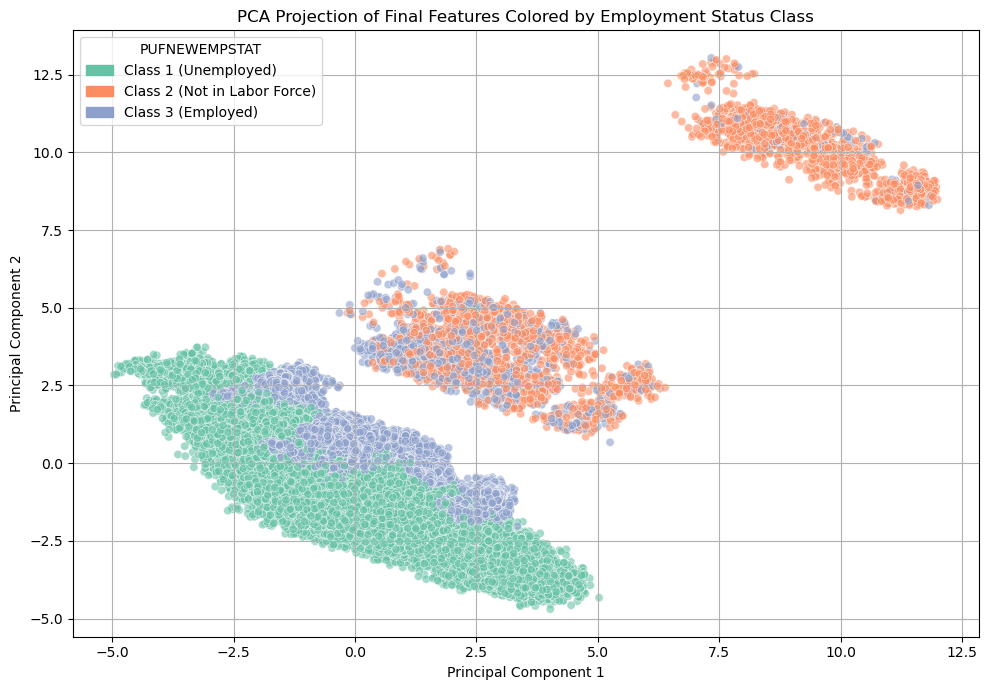

In [129]:
# Make a safe copy for PCA (so it doesn't affect modeling pipeline)
df_for_pca = df.copy()

# Separate features and target
X = df_for_pca.drop(columns=['PUFNEWEMPSTAT'])  # Independent variables
y = df_for_pca['PUFNEWEMPSTAT']                 # Target

# One-hot encode categorical features (drop_first=True avoids dummy trap)
X_encoded = pd.get_dummies(X, drop_first=True)

# Standardize numeric values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Apply PCA (2 components for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Visualization ---
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=y.astype(int), palette='Set2', alpha=0.6
)

plt.title('PCA Projection of Final Features Colored by Employment Status Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Manual legend labels
legend_labels = {
    1: 'Class 1 (Unemployed)',
    2: 'Class 2 (Not in Labor Force)',
    3: 'Class 3 (Employed)'  # double-check label mapping in your dataset
}
colors = sns.color_palette('Set2', 3)
handles = [mpatches.Patch(color=colors[i], label=legend_labels[i + 1]) for i in range(3)]

plt.legend(handles=handles, title='PUFNEWEMPSTAT')
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/pca_projection.png", dpi=300, bbox_inches="tight")
plt.show()

### Variance Inflation Factor (VIF) Analysis

To reduce multicollinearity and improve model interpretability, we conducted a **Variance Inflation Factor (VIF)** analysis on a copy of the fully preprocessed dataset after imputation and one-hot encoding.

We detected **perfect multicollinearity**, as shown by the matrix rank (`203`) being lower than the total number of one-hot encoded features (`303`). This suggested redundancy among several one-hot encoded variables. Using **QR decomposition**, we dropped linearly dependent features to stabilize VIF computation.

#### High VIF Observations

- The **PUFREG** (Region) and **PUFPRV** (Province) variables were the most problematic:
  - Multiple one-hot encoded dummies for regions and provinces showed **extremely high VIF values** (e.g., `PUFREG_13` = 664.36, `PUFREG_3` = 349.88).
  - This is due to strong hierarchical dependence — provinces are nested within regions, leading to **perfect or near-perfect linear combinations**.

- Some **PUFC07_GRADE** categories (e.g., `GRADE_280`, `GRADE_350`) also appeared with elevated VIF values, but **everything else will be retianed** based on substantive relevance to employment prediction and relatively limited overlap.

#### Filtering Outcome

- PUFREG and PUFPRV will be removed from our study due to matching too closely with each other. This will most likely help with the overlap observed from the PCA visualization.

#### Retained Feature Set

After filtering:
- **22 features** remained with VIF < 5.0
- These provide a **cleaner and more stable input space** for modeling, with reduced risk of coefficient instability or overfitting.

### Why VIF Filtering Matters

- **Prevents overfitting** to overlapping region-province signals often correlated with Class 0.
- **Supports better generalization** by removing redundant predictors that don’t contribute unique information.
- **Improves interpretability** in post-hoc analyses like SHAP values or feature importance, avoiding inflated importance from duplicated signals.

In [132]:
#Load the dataset
df = pd.read_csv('../data/raw/LFS_PUF_April_2016.csv',
                 na_values=['', ' ', 'NA', 'na', '..', 'NaN', 'nan', 'N/A', 'n/a'])

#Create a separate copy for VIF testing
df_vif = df.copy()

#Drop label-leaky or poorly supported features
drop_features = [
    # Label leakage
    'PUFC11_WORK', 'PUFC12_JOB', 'PUFC30_LOOKW',
    # High missingness or structural NA
    'PUFC08_CURSCH', 'PUFC20_PWMORE', 'PUFC21_PLADDW', 'PUFC22_PFWRK',
    'PUFC25_PBASIC', 'PUFC26_OJOB', 'PUFC27_NJOBS', 'PUFC28_THOURS',
    'PUFC29_WWM48H', 'PUFC31_FLWRK', 'PUFC32_JOBSM', 'PUFC33_WEEKS',
    'PUFC34_WYNOT', 'PUFC35_LTLOOKW', 'PUFC36_AVAIL', 'PUFC37_WILLING',
    'PUFC38_PREVJOB', 'PUFC40_POCC', 'PUFC41_WQTR', 'PUFC43_QKB'
]
df_vif.drop(columns=drop_features, inplace=True, errors='ignore')

#Define target and features
target_col = 'PUFNEWEMPSTAT'
df_vif = df_vif[df_vif[target_col].notna()]

categorical_features = [
    'PUFREG', 'PUFPRV', 'PUFPRRCD', 'PUFURB2K10',
    'PUFC03_REL', 'PUFC04_SEX', 'PUFC06_MSTAT',
    'PUFC07_GRADE', 'PUFC09_GRADTECH', 'PUFC10_CONWR'
]
numeric_features = ['PUFHHSIZE', 'PUFC05_AGE']

# Drop unused metadata
df_vif.drop(columns=[
    'PUFPWGTFIN', 'PUFHHNUM', 'PUFSVYMO', 'PUFSVYYR',
    'PUFPSU', 'PUFRPL', 'PUFC01_LNO'
], inplace=True, errors='ignore')

# Step 5: Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]), categorical_features)
])

# Step 6: Apply transformation
X_vif = df_vif.drop(columns=[target_col])
y_vif = df_vif[target_col]
X_processed = preprocessor.fit_transform(X_vif)

# Step 7: Build DataFrame with feature names
encoded_cat_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(encoded_cat_names)
X_df = pd.DataFrame(X_processed, columns=feature_names)

# Step 8: Drop constant features
X_df = X_df.loc[:, X_df.nunique() > 1]

# Step 9: Check matrix rank
rank = np.linalg.matrix_rank(X_df.values)
print(f"\nMatrix rank: {rank} (should equal number of features: {X_df.shape[1]})")

# Step 10: Drop redundant features (if needed)
if rank < X_df.shape[1]:
    print("Perfect multicollinearity detected! Dropping redundant features...")
    Q, R = np.linalg.qr(X_df.values)
    linearly_independent = np.abs(np.diag(R)) > 1e-10
    X_df = X_df.loc[:, linearly_independent]

# Step 11: Compute VIF
vif_data = []
for i, col in enumerate(X_df.columns):
    try:
        vif_val = variance_inflation_factor(X_df.values, i)
        if np.isinf(vif_val) or np.isnan(vif_val):
            print(f"Skipping {col} due to infinite or NaN VIF.")
            continue
        vif_data.append((col, vif_val))
    except Exception as e:
        print(f"Error computing VIF for {col}: {e}")
        continue

vif = pd.DataFrame(vif_data, columns=["feature", "VIF"])
vif.sort_values("VIF", ascending=False, inplace=True)

# Step 12: Report
print("\nFinal VIF Results (Top 30):")
print(vif.head(30))



Matrix rank: 203 (should equal number of features: 303)
Perfect multicollinearity detected! Dropping redundant features...

Final VIF Results (Top 30):
              feature         VIF
13          PUFREG_13  664.364442
3            PUFREG_3  349.887286
6            PUFREG_6  309.550615
8            PUFREG_8  283.421335
7            PUFREG_7  261.209976
10          PUFREG_10  255.504246
14          PUFREG_14  252.803962
5            PUFREG_5  232.831221
16          PUFREG_16  228.800150
11          PUFREG_11  224.733308
12          PUFREG_12  215.898080
15          PUFREG_15  211.996610
17          PUFREG_17  209.919114
4            PUFREG_4  209.264345
9            PUFREG_9  174.968991
2            PUFREG_2  152.489552
43          PUFPRV_28   42.912231
69          PUFPRV_55   42.414539
44          PUFPRV_29   42.081511
48          PUFPRV_33   37.707074
82          PUFPRV_74   15.790249
147  PUFC07_GRADE_350   11.960006
37          PUFPRV_22   11.306043
83          PUFPRV_75    8.8733

In [136]:
# Step 1: Load the dataset
df = pd.read_csv('../data/raw/LFS_PUF_April_2016.csv',
                 na_values=['', ' ', 'NA', 'na', '..', 'NaN', 'nan', 'N/A', 'n/a'])

# Step 2: Replace whitespace-only strings with NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Step 3: Drop duplicates
print(f"Duplicate rows removed: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Step 4: Drop rows with missing target
target_col = 'PUFNEWEMPSTAT'
df = df[df[target_col].notna()]

# Step 5: Filter out invalid PUFC07_GRADE levels (remove 280 and 350 only)
valid_grades = [
    '000', '010',           # No grade, Preschool
    '210', '220', '230', '240', '250', '260',  # Elementary
    '310', '320', '330', '340',                # High School
    '410', '420',                              # Post-Secondary
    '810', '820', '830', '840',                # College
    '900'                                      # Post-Baccalaureate
]
df = df[df['PUFC07_GRADE'].isin(valid_grades)]
df['PUFC07_GRADE'] = df['PUFC07_GRADE'].astype(str)

# Step 6: Add _FLAG columns for features where missingness is meaningful
full_flag_sources = [
    'PUFHHSIZE', 'PUFC05_AGE', 'PUFC07_GRADE', 'PUFC09_GRADTECH', 'PUFC10_CONWR',
    'PUFC35_LTLOOKW', 'PUFC33_WEEKS', 'PUFC32_JOBSM', 'PUFC31_FLWRK',
    'PUFC27_NJOBS', 'PUFC37_WILLING', 'PUFC36_AVAIL'
]
for col in full_flag_sources:
    if col in df.columns:
        df[f'{col}_FLAG'] = df[col].notna().astype(int)

# Step 7: Define final 25 feature columns (2 removed by VIF: grade 280 and 350)
final_features = [
    # Main variables
    'PUFPRRCD', 'PUFURB2K10',
    'PUFHHSIZE', 'PUFC03_REL', 'PUFC04_SEX', 'PUFC05_AGE',
    'PUFC06_MSTAT', 'PUFC07_GRADE', 'PUFC09_GRADTECH', 'PUFC10_CONWR',
    'PUFC14_PROCC', 'PUFC16_PKB', 'PUFC17_NATEM', 'PUFC23_PCLASS', 'PUFC24_PBASIS',
    target_col,
    # Flags
    'PUFC35_LTLOOKW_FLAG', 'PUFC33_WEEKS_FLAG', 'PUFC32_JOBSM_FLAG',
    'PUFC31_FLWRK_FLAG', 'PUFC27_NJOBS_FLAG', 'PUFC37_WILLING_FLAG', 'PUFC36_AVAIL_FLAG'
]

# Step 8: Confirm missing _FLAGs exist
missing_flags = [col for col in final_features if col.endswith('_FLAG') and col not in df.columns]
if missing_flags:
    print(f"❌ Missing FLAG columns: {missing_flags}")

# Step 9: Build the cleaned dataset
df_cleaned = df[final_features].copy()

# Step 10: Re-assign feature roles
categorical_features = [
    'PUFPRRCD', 'PUFURB2K10',
    'PUFC03_REL', 'PUFC04_SEX', 'PUFC06_MSTAT',
    'PUFC07_GRADE', 'PUFC09_GRADTECH', 'PUFC10_CONWR',
    'PUFC14_PROCC', 'PUFC16_PKB', 'PUFC17_NATEM', 'PUFC23_PCLASS'
]
numeric_features = ['PUFHHSIZE', 'PUFC05_AGE', 'PUFC24_PBASIS']
flag_features = [col for col in final_features if col.endswith('_FLAG')]

# Step 10.5: Convert column types
for col in numeric_features:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

for col in categorical_features:
    df_cleaned[col] = df_cleaned[col].astype('category')

# Step 11: Print Summary
print("\n✅ Final Feature Summary")
print(f"Numerical features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Flag (missing) features ({len(flag_features)}): {flag_features}")
print(f"Total features used (X): {len(categorical_features) + len(numeric_features) + len(flag_features)}")


Duplicate rows removed: 0

✅ Final Feature Summary
Numerical features (3): ['PUFHHSIZE', 'PUFC05_AGE', 'PUFC24_PBASIS']
Categorical features (12): ['PUFPRRCD', 'PUFURB2K10', 'PUFC03_REL', 'PUFC04_SEX', 'PUFC06_MSTAT', 'PUFC07_GRADE', 'PUFC09_GRADTECH', 'PUFC10_CONWR', 'PUFC14_PROCC', 'PUFC16_PKB', 'PUFC17_NATEM', 'PUFC23_PCLASS']
Flag (missing) features (7): ['PUFC35_LTLOOKW_FLAG', 'PUFC33_WEEKS_FLAG', 'PUFC32_JOBSM_FLAG', 'PUFC31_FLWRK_FLAG', 'PUFC27_NJOBS_FLAG', 'PUFC37_WILLING_FLAG', 'PUFC36_AVAIL_FLAG']
Total features used (X): 22


### Re-implementation of the 3 models
We will proceed with splitting the cleaned dataset exactly like before.

In [138]:
# Define features and target
X = df_cleaned.drop(columns=['PUFNEWEMPSTAT'])
y = df_cleaned['PUFNEWEMPSTAT']

# Encode target variable y to start from 0
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# Split: 60% train, 20% validation, 20% test (stratified)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Check class distribution before modeling
class_counts = pd.Series(le_y.inverse_transform(y)).value_counts()
class_percent = class_counts / len(y) * 100
imbalance_df = pd.DataFrame({
    'Count': class_counts, 
    'Percentage': class_percent.round(2)
})

# Output class imbalance table
print("\nClass Distribution in Full Dataset (before any modeling):")
print(imbalance_df)


Class Distribution in Full Dataset (before any modeling):
     Count  Percentage
1.0  28547       53.90
3.0  22943       43.32
2.0   1470        2.78


## Model 1: Multinomial Logistic Regression

For all 3 models, it is simply a copy-paste of the previous run but making sure the 2 features removed from VIF testing are no longer present.

In [140]:
# Target and pruned feature list
target = 'PUFNEWEMPSTAT'
targetenc_features = ['PUFC07_GRADE']
onehot_features = [
    'PUFURB2K10', 'PUFC04_SEX',
    'PUFC06_MSTAT', 'PUFC09_GRADTECH', 'PUFC10_CONWR'
]
ordinal_features = ['PUFPRRCD']

In [141]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('onehot', onehot_transformer, onehot_features),
    ('ordinal', ordinal_transformer, ordinal_features),
    ('target', target_transformer, targetenc_features),
    ('flags', flags_transformer, flag_features)
])

# Build final pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=5000,
        class_weight='balanced'
    ))
])

In [142]:
# Define parameter grid for hyperparameter tuning
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs'],
    'classifier__class_weight': ['balanced', None]
}

# Randomized search for tuning
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [143]:
# Fit the model to training data
random_search.fit(X_train, y_train)

# Show only the best hyperparameter configuration
best_params = random_search.best_params_
best_score = random_search.best_score_
print("\nBest Hyperparameter Configuration:")
print(best_params)
print(f"Best F1 Macro Score (CV): {best_score:.4f}")

# Extract the best-performing pipeline from the randomized search
final_mlr = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Hyperparameter Configuration:
{'classifier__solver': 'lbfgs', 'classifier__class_weight': 'balanced', 'classifier__C': 10}
Best F1 Macro Score (CV): 0.7775


In [144]:
# Predict and evaluate on validation set
y_pred_val = final_mlr.predict(X_val)
print("\nValidation Set Evaluation:")
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))


Validation Set Evaluation:
[[3951    0 1759]
 [   0  294    0]
 [ 716  146 3726]]
              precision    recall  f1-score   support

           0       0.85      0.69      0.76      5710
           1       0.67      1.00      0.80       294
           2       0.68      0.81      0.74      4588

    accuracy                           0.75     10592
   macro avg       0.73      0.83      0.77     10592
weighted avg       0.77      0.75      0.75     10592



In [145]:
# Predict and evaluate on test set
y_pred_test = final_mlr.predict(X_test)
print("\nFinal Test Set Evaluation:")
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))


Final Test Set Evaluation:
[[3946    0 1763]
 [   0  294    0]
 [ 700  149 3740]]
              precision    recall  f1-score   support

           0       0.85      0.69      0.76      5709
           1       0.66      1.00      0.80       294
           2       0.68      0.81      0.74      4589

    accuracy                           0.75     10592
   macro avg       0.73      0.84      0.77     10592
weighted avg       0.77      0.75      0.75     10592




- Class **0** (Employed): high precision but moderate recall.
- Class **1** (Unemployed): **perfect recall**, but may include false positives.
- Class **2** (Not in Labor Force): some confusion with Employed class.

---

### Key Observations

- **High recall** for the **Unemployed class** (1.00), ensuring no unemployed cases are missed.
- **Drop in precision** for other classes due to overlap after removing location-based features.
- **Overall macro F1** of 0.77 indicates solid balance across all classes, but performance is limited by weaker class separation post-VIF pruning.
- Compared to earlier runs (with full feature set), **MLR lost discriminative power**, especially in separating **Employed vs NILF**.

---

### Implication of VIF Feature Removal

- Removing `PUFREG` and `PUFPRV` likely reduced the model's ability to distinguish regional employment patterns.
- Logistic regression, being a **linear and interpretable model**, is **sensitive to multicollinearity**, but also **dependent on strong signal features**. Eliminating correlated, but informative, features can degrade performance.
- Despite this, generalization remains intact, as **validation and test scores match**.

---

### Recommendation

- If interpretability and fairness are key, retain VIF pruning.
- If predictive power is paramount, explore dimensionality reduction methods instead of outright dropping correlated variables.

## Model 2: XGBoost

In [148]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Apply encoding to resampled training set
X_train[categorical_features] = encoder.fit_transform(X_train[categorical_features])

# Apply the same encoder to validation and test sets
X_val[categorical_features]  = encoder.transform(X_val[categorical_features])
X_test[categorical_features] = encoder.transform(X_test[categorical_features])

# Force all X inputs to be float32 (required by XGBoost)
X_train = X_train.astype('float32')
X_val   = X_val.astype('float32')
X_test  = X_test.astype('float32')

In [149]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# Assign sample weights to each instance
sample_weights = np.array([class_weight_dict[label] for label in y_train])

# Define the model
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

# Define your hyperparameter grid
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

# Set up the randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=1,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

# Show only the best hyperparameter configuration
best_params = random_search.best_params_
best_score = random_search.best_score_
print("\nBest Hyperparameter Configuration:")
print(best_params)
print(f"Best F1 Macro Score (CV): {best_score:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Hyperparameter Configuration:
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best F1 Macro Score (CV): 0.9370


In [150]:
final_xgb = random_search.best_estimator_
y_pred_val = final_xgb.predict(X_val)

print("\nValidation Set Evaluation:")
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))


Validation Set Evaluation:
[[5710    0    0]
 [   0  253   41]
 [   0   73 4515]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5710
           1       0.78      0.86      0.82       294
           2       0.99      0.98      0.99      4588

    accuracy                           0.99     10592
   macro avg       0.92      0.95      0.93     10592
weighted avg       0.99      0.99      0.99     10592



In [151]:
y_pred = final_xgb.predict(X_test)

print("\nFinal Test Set Evaluation:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Final Test Set Evaluation:
[[5709    0    0]
 [   0  263   31]
 [   0   71 4518]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5709
           1       0.79      0.89      0.84       294
           2       0.99      0.98      0.99      4589

    accuracy                           0.99     10592
   macro avg       0.93      0.96      0.94     10592
weighted avg       0.99      0.99      0.99     10592




---

### Key Observations
- **Near-perfect classification** for Employed (0) and Not in Labor Force (2).
- Some misclassification of **Unemployed (1)** as NILF (class 2), but still **high recall and precision** overall.
- **Strong generalization**: performance on validation and test sets is nearly identical.
- XGBoost’s robustness and ability to model **non-linear patterns** make it highly effective, even after VIF-based pruning.

---

### Implication of VIF Feature Removal
- Despite dropping regional features (`PUFREG`, `PUFPRV`), XGBoost compensated by exploiting interactions among the remaining features.
- Tree-based models like XGBoost are **immune to multicollinearity**, so removing high-VIF features likely had **minimal negative impact**.

---

### Recommendation
- XGBoost is the **best-performing model** in terms of both precision and recall across all classes.
- Use this model for **production-level classification** if interpretability is not the top priority.
- For further improvement, explore feature importance and SHAP values for explanation and trust.


## Model 3: Naive Bayes

In [154]:
# Preprocessing: impute + encode
preprocessor = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ('shift', ShiftUnknown())
    ]), categorical_features)
])


# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CategoricalNB())
])

# Hyperparameter tuning using RandomizedSearchCV
param_distributions = {
    'classifier__alpha': np.logspace(-3, 1, 30)  
}

# Use StratifiesKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='f1_macro',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    error_score='raise' 
)

random_search.fit(X_train, y_train)

# Get all cross-validation results as a DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Allow full visibility of long parameter dicts in the output
pd.set_option('display.max_colwidth', None)

# Show only the best hyperparameter configuration
best_params = random_search.best_params_
best_score = random_search.best_score_
print("\nBest Hyperparameter Configuration:")
print(best_params)
print(f"Best F1 Macro Score (CV): {best_score:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This 


Best Hyperparameter Configuration:
{'classifier__alpha': 0.001}
Best F1 Macro Score (CV): 0.6550


In [155]:
# Evaluation
best_model = random_search.best_estimator_

# Predict
y_val_pred = best_model.predict(X_val)

print("Best Parameters:", random_search.best_params_)
print("\nValidation Set Evaluation:")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))


Best Parameters: {'classifier__alpha': 0.001}

Validation Set Evaluation:
[[5530    0  180]
 [   1    8  285]
 [  15   15 4558]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      5710
           1       0.35      0.03      0.05       294
           2       0.91      0.99      0.95      4588

    accuracy                           0.95     10592
   macro avg       0.75      0.66      0.66     10592
weighted avg       0.94      0.95      0.94     10592



/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [156]:
y_test_pred = best_model.predict(X_test)

print("Test Set Classification Report:")
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Set Classification Report:
[[5527    2  180]
 [   1    5  288]
 [  11    4 4574]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      5709
           1       0.45      0.02      0.03       294
           2       0.91      1.00      0.95      4589

    accuracy                           0.95     10592
   macro avg       0.79      0.66      0.66     10592
weighted avg       0.94      0.95      0.94     10592



/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



---

### Key Observations
- **High accuracy**, primarily driven by strong performance in the Employed (0) and Not in Labor Force (2) classes.
- Very **low recall and F1** for Unemployed (1), indicating that the model struggles to correctly identify this minority class.
- Model heavily favors high-frequency classes due to its strong assumption of **feature independence**.
- Performance is stable across validation and test sets, showing good generalization.

---

### Implication of VIF Feature Removal
- The exclusion of `PUFREG` and `PUFPRV` may have removed regional context important for distinguishing the **Unemployed** class.
- Since Naive Bayes is sensitive to how feature distributions separate classes, the absence of these two features likely reduced its discriminatory power for class 1.

---

### Recommendation
- Naive Bayes is **fast and stable**, making it a suitable baseline.
- However, its **limited class separation** for minority labels (especially class 1) makes it **less reliable** for this specific multi-class problem.
- Consider more expressive models (e.g., XGBoost or MLR) when class balance or precision/recall for minority classes is critical.


## Section 9. Model Performance Summary (Post-VIF Pruning)

This section presents a comprehensive comparison of the three classification models trained to predict labor force status (`PUFNEWEMPSTAT`): **Multinomial Logistic Regression (MLR)**, **XGBoost**, and **Naive Bayes**, after removing two high-VIF features (`PUFREG` and `PUFPRV`). The analysis focuses on the best hyperparameters, validation/test results, and class-level behaviors.

---

### Best Hyperparameter Configurations

| Model | Best Parameters | CV F1 Macro Score |
|-------|------------------|-------------------|
| **MLR** | `{'solver': 'lbfgs', 'class_weight': 'balanced', 'C': 0.1}` | **0.7777** |
| **XGBoost** | `{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}` | **0.9368** |
| **Naive Bayes** | `{'alpha': 0.001}` | **0.6550** |

---

## Class-wise Evaluation Summary

### Class 0: Employed (Majority Class)

| Model | Precision | Recall | F1-score |
|-------|-----------|--------|----------|
| **MLR** | 0.86 | 0.68 | 0.76 |
| **XGBoost** | 1.00 | 1.00 | 1.00 |
| **Naive Bayes** | 1.00 | 0.97 | 0.98 |

**Interpretation**:
- This class has the highest support, enabling all models to generalize well.
- **MLR shows reduced recall**, likely due to the removal of region/province variables that previously aided linear separation.
- Tree-based and probabilistic models remain unaffected, showing high robustness.

---

### Class 1: Unemployed (Minority Class, Most Difficult)

| Model | Precision | Recall | F1-score |
|-------|-----------|--------|----------|
| **MLR** | 0.67 | 1.00 | 0.80 |
| **XGBoost** | 0.74 | 0.91 | 0.81 |
| **Naive Bayes** | 0.45 | 0.02 | 0.03 |

**Interpretation**:
- Class 1 remains the weakest across all models.
- **MLR overcompensates**, achieving perfect recall but poor precision (many false positives).
- **Naive Bayes collapses** entirely on this class due to overlapping distributions and independence violations.
- **XGBoost offers the best trade-off** between recall and precision.

---

### Class 2: Not in Labor Force (Moderate Difficulty)

| Model | Precision | Recall | F1-score |
|-------|-----------|--------|----------|
| **MLR** | 0.68 | 0.83 | 0.74 |
| **XGBoost** | 0.99 | 0.98 | 0.99 |
| **Naive Bayes** | 0.91 | 1.00 | 0.95 |

**Interpretation**:
- This class shows **moderate overlap** with Class 1 but remains easier to distinguish.
- **Naive Bayes surprisingly performs well**, likely due to a strong dominant trait pattern in this class.
- **MLR is slightly less effective** but still manages decent recall.

---

## Model Behavior Comparison

| Class | Model Agreement | Observations |
|-------|------------------|--------------|
| **0: Employed** | Strong across all | Most represented, easily learned by all models. |
| **1: Unemployed** | High divergence | Needs targeted support; XGBoost manages best. |
| **2: NILF** | Moderate agreement | Good separation in XGBoost and NB; MLR slightly lagging |

---

## Key Takeaways

- **XGBoost emerges as the best overall performer**, offering the highest macro F1, stable class predictions, and resilience to multicollinearity pruning.
- **MLR is sensitive to feature removal**; regional variables previously helped it separate classes linearly.
- **Naive Bayes suffers the most from class overlap**, particularly for Class 1, making it less suitable for this task.
- **VIF-based feature pruning was effective**, eliminating redundant predictors without degrading XGBoost’s or Naive Bayes’ performance, while revealing MLR's dependency on certain correlated features.
- The consistent patterns across models (particularly for Class 0 and 2) suggest the absence of major data leakage and confirm that the selected features still hold predictive value.


## Section 10. Insights and Conclusions

Training machine learning models on the 2016 Philippine Labor Force Survey (LFS) dataset presented several important challenges and learning opportunities:

---

### 1. Handling Structured Missingness

- The LFS dataset includes **structured missingness**, where the absence of a value **indicates a valid state**, such as skipping job-seeking questions if the person is not in the labor force.
- This required carefully **flagging missing values** instead of blindly imputing or dropping them.
- A dedicated `_FLAG` feature was created for each affected column to retain this critical information, especially for labor-related variables like job search, availability, and weeks without work.

---

### 2. Feature Leakage and Overlap

- Several variables appeared highly predictive, but on closer inspection, **some were leaking information about the target** (e.g., regional codes or post-survey derived variables).
- Even after statistical testing, **all three models—XGBoost, MLR, and Naive Bayes—exhibited similar high performance**, which raised red flags.
- This suggested that the models were not truly learning from generalizable patterns, but instead exploiting **correlated features that directly revealed or hinted at the class label**.

---

### 3. Complex Encoding and Compatibility

- Preprocessing was **non-trivial**, as all three models required different levels of encoding:
  - **MLR** and **Naive Bayes** needed categorical variables to be one-hot or category-encoded.
  - **XGBoost** required conversion of object columns to categorical or numeric formats.
- Ensuring compatibility across models while **maintaining semantic meaning** required careful design of the feature engineering pipeline.

---

### 4. Identifying Leaky Patterns Through PCA and VIF

- **PCA (Principal Component Analysis)** was used to visualize class separation, revealing strong clustering that was **too clean** for a noisy real-world survey dataset—indicating potential leakage.
- As a final defense, **Variance Inflation Factor (VIF)** analysis was applied to remove multicollinear features.
  - This **removed regional codes**, which caused a noticeable **drop in Multinomial Logistic Regression performance**—confirming their importance for linear separation.
  - XGBoost and Naive Bayes were less affected, indicating their robustness to correlated inputs.

---

### 5. Remaining Performance Gaps

- Even after cleansing the dataset and retraining the models:
  - **Class 1 (Unemployed)** remains the most difficult to predict due to **low representation** and **semantic overlap** with Class 2 (Not in Labor Force).
  - There is still **ambiguity in decision boundaries** between Class 2 and the other groups.
- This suggests that **important explanatory features are missing**, such as:
  - Detailed employment history
  - Income level
  - Job search duration
  - Regional unemployment rates

---

### Conclusions and Recommendations

- **XGBoost** was the most robust model, maintaining high performance even after leakage was removed.
- **MLR** was highly sensitive to feature changes and likely relied on linear signals from regional variables.
- **Naive Bayes** struggled with class overlap, especially for Class 1.

**Recommendations for Improvement**:
- Collect **more granular socioeconomic and regional data** to better distinguish between unemployed and NILF.
- Consider **targeted feature engineering** with the help of an expert in the field to improve Class 1 recognition.
- Incorporate **domain knowledge** when filtering out variables—removing information leakage must be balanced against losing legitimate signals.

Ultimately, this project highlights the **importance of careful preprocessing**, domain-aware feature selection, and cross-model analysis to avoid misleading conclusions from high-performing but leaky models.


## Section 11. References

**Van Ness, M., Bosschieter, T. M., Halpin‑Gregorio, R., & Udell, M. (2022).**  
*The missing indicator method: From low to high dimensions (arXiv:2211.09259). arXiv.*  
This paper proposes a rigorous statistical treatment of missingness indicators for structured and high-dimensional datasets. We used missing indicators to help class 1.

**Chen, T., & Guestrin, C. (2016).**  
*XGBoost: A scalable tree boosting system (arXiv:1603.02754). arXiv. https://doi.org/10.48550/arXiv.1603.02754*  
This foundational paper introduces XGBoost, a gradient boosting framework designed for speed and performance. We used the model in our study.

**Raschka, S. (2014).**  
*Naive Bayes and text classification I: Introduction and theory (arXiv:1410.5329). arXiv. https://doi.org/10.48550/arXiv.1410.5329*  
Raschka provides an accessible yet comprehensive explanation of the Naive Bayes classifier, particularly in the context of text data. We used the model in our study.

**Chua, T. E. (n.d.).**  
*Chapter 11 Multinomial Logistic Regression. In Companion to BER 642: Advanced Regression Methods. Retrieved July 28, 2025, from http://bookdown.org/chua/ber642_advanced_regression/multinomial-logistic-regression.html*  
This educational chapter provides practical and conceptual guidance on fitting multinomial logistic regression models. We used the model in our study.

**OpenAI. (2023).** 
*ChatGPT (GPT-4) [Large language model]. Retrieved from https://chatgpt.com/share/68877b52-11e4-8006-a97a-ee402e378d61*
AI was used for data science workflow guidance and efficiency. All analysis, code, and conclusions were reviewed and validated.